# Classification [Symbol Detection]

## Dataset Setup
  - parsing large dataset to create a one single folder
  of all different sybmols

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# -- Zip paths --
data_batch3_01 = "/content/drive/MyDrive/Symbol_Detection/Classification/Raw_Images_Symbols/Roboflow\ Output/Sonam\ Z1.v5i.yolov8.zip"
data_batch3_02 = "/content/drive/MyDrive/Symbol_Detection/Classification/Raw_Images_Symbols/Roboflow\ Output/Sonam\ Z2.v5i.yolov8.zip"
data_batch3_03 = "/content/drive/MyDrive/Symbol_Detection/Classification/Raw_Images_Symbols/Roboflow\ Output/Tshering.v5i.yolov8.zip"
data_batch5_01 = "/content/drive/MyDrive/Symbol_Detection/Classification/Raw_Images_Symbols/Roboflow\ Output/Batch\ 5\ -\ raw_annotated_dataset.v5i.yolov8.zip"
data_batch6_01 = "/content/drive/MyDrive/Symbol_Detection/Classification/Raw_Images_Symbols/Roboflow\ Output/Batch\ 6\ -\ raw_annotated_dataset.v5i.yolov8.zip"
data_batch7_01 = "/content/drive/MyDrive/Symbol_Detection/Classification/Raw_Images_Symbols/Roboflow\ Output/Batch\ 7-\ raw_annotated_dataset_05.v5i.yolov8.zip"
data_batch4_01 = "/content/drive/MyDrive/Symbol_Detection/Classification/Raw_Images_Symbols/Roboflow\ Output/batch-4-raw_annotated_dataset.v5i.yolov8.zip"
data_batch8_01 = "/content/drive/MyDrive/Symbol_Detection/Classification/Raw_Images_Symbols/Roboflow\ Output/batch_8_raw_annotated_dataset.v4i.yolov8.zip"
data_batch2_01 = "/content/drive/MyDrive/Symbol_Detection/Classification/Raw_Images_Symbols/Roboflow\ Output/Split_Images.v7i.yolov8.zip"
data_batch1_01 = "/content/drive/MyDrive/Symbol_Detection/Classification/Raw_Images_Symbols/Roboflow\ Output/My\ First\ Project.v5i.yolov8.zip"



# -- unzip dataset paths --
!unzip -q {data_batch3_01} -d data_batch3_01
!unzip -q {data_batch3_02} -d data_batch3_02
!unzip -q {data_batch3_03} -d data_batch3_03
!unzip -q {data_batch5_01} -d data_batch5_01
!unzip -q {data_batch6_01} -d data_batch6_01
!unzip -q {data_batch7_01} -d data_batch7_01
!unzip -q {data_batch4_01} -d data_batch4_01
!unzip -q {data_batch8_01} -d data_batch8_01
!unzip -q {data_batch2_01} -d data_batch2_01
!unzip -q {data_batch1_01} -d data_batch1_01

unzip:  cannot find or open /content/drive/MyDrive/Symbol_Detection/Classification/Raw_Images_Symbols/Roboflow Output/Sonam Z1.v5i.yolov8.zip, /content/drive/MyDrive/Symbol_Detection/Classification/Raw_Images_Symbols/Roboflow Output/Sonam Z1.v5i.yolov8.zip.zip or /content/drive/MyDrive/Symbol_Detection/Classification/Raw_Images_Symbols/Roboflow Output/Sonam Z1.v5i.yolov8.zip.ZIP.


<>:2: SyntaxWarning: invalid escape sequence '\ '
<>:3: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\ '
<>:5: SyntaxWarning: invalid escape sequence '\ '
<>:6: SyntaxWarning: invalid escape sequence '\ '
<>:7: SyntaxWarning: invalid escape sequence '\ '
<>:8: SyntaxWarning: invalid escape sequence '\ '
<>:9: SyntaxWarning: invalid escape sequence '\ '
<>:10: SyntaxWarning: invalid escape sequence '\ '
<>:11: SyntaxWarning: invalid escape sequence '\ '
<>:2: SyntaxWarning: invalid escape sequence '\ '
<>:3: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\ '
<>:5: SyntaxWarning: invalid escape sequence '\ '
<>:6: SyntaxWarning: invalid escape sequence '\ '
<>:7: SyntaxWarning: invalid escape sequence '\ '
<>:8: SyntaxWarning: invalid escape sequence '\ '
<>:9: SyntaxWarning: invalid escape sequence '\ '
<>:10: SyntaxWarning: invalid escape sequence '\ '
<>:11: SyntaxWarning: invalid escape sequence '

unzip:  cannot find or open /content/drive/MyDrive/Symbol_Detection/Classification/Raw_Images_Symbols/Roboflow Output/Sonam Z2.v5i.yolov8.zip, /content/drive/MyDrive/Symbol_Detection/Classification/Raw_Images_Symbols/Roboflow Output/Sonam Z2.v5i.yolov8.zip.zip or /content/drive/MyDrive/Symbol_Detection/Classification/Raw_Images_Symbols/Roboflow Output/Sonam Z2.v5i.yolov8.zip.ZIP.
unzip:  cannot find or open /content/drive/MyDrive/Symbol_Detection/Classification/Raw_Images_Symbols/Roboflow Output/Tshering.v5i.yolov8.zip, /content/drive/MyDrive/Symbol_Detection/Classification/Raw_Images_Symbols/Roboflow Output/Tshering.v5i.yolov8.zip.zip or /content/drive/MyDrive/Symbol_Detection/Classification/Raw_Images_Symbols/Roboflow Output/Tshering.v5i.yolov8.zip.ZIP.
unzip:  cannot find or open /content/drive/MyDrive/Symbol_Detection/Classification/Raw_Images_Symbols/Roboflow Output/Batch 5 - raw_annotated_dataset.v5i.yolov8.zip, /content/drive/MyDrive/Symbol_Detection/Classification/Raw_Images_Sy

### Load & Verify Dataset

In [ ]:
###################################################
# script for verifying the dataset
# format of input data
#   - images (.jpg, .png ....)
#   - labels (yolo_format_annotations(cls, x_cen, y_cen, width, height)) # normalized values
#####################################################
import os
import cv2

images_path = "/content/data_batch1_01/train/images"
labels_path = "/content/data_batch1_01/train/labels"
write_img_dir = "/content/output_images"
patch_size = 1792  # Not directly used unless you want to draw grid or check sizes

# 80 bright visible colors
colors = [
(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (0, 255, 255),
(255, 0, 255), (255, 128, 0), (128, 0, 255), (0, 128, 255), (128, 255, 0),
(255, 0, 128), (0, 255, 128), (128, 255, 255), (255, 128, 128), (128, 128, 255),
(255, 255, 128), (128, 255, 128), (255, 128, 255), (192, 0, 0), (0, 192, 0),
(0, 0, 192), (192, 192, 0), (0, 192, 192), (192, 0, 192), (255, 64, 0),
(64, 0, 255), (0, 64, 255), (64, 255, 0), (255, 0, 64), (0, 255, 64),
(64, 255, 255), (255, 200, 0), (200, 0, 255), (0, 200, 255), (200, 255, 0),
(255, 0, 200), (0, 255, 200), (200, 255, 255), (255, 100, 50), (50, 100, 255),
(100, 50, 255), (50, 255, 100), (255, 50, 100), (100, 255, 50), (255, 150, 0),
(150, 0, 255), (0, 150, 255), (150, 255, 0), (255, 0, 150), (0, 255, 150),
(150, 255, 255), (255, 180, 75), (75, 180, 255), (180, 75, 255), (75, 255, 180),
(255, 75, 180), (180, 255, 75), (230, 30, 30), (30, 230, 30), (30, 30, 230),
(230, 230, 30), (30, 230, 230), (230, 30, 230), (255, 210, 60), (60, 210, 255),
(210, 60, 255), (60, 255, 210), (255, 60, 210), (210, 255, 60), (255, 80, 160),
(80, 160, 255), (160, 80, 255), (80, 255, 160), (255, 160, 80), (160, 255, 80),
(100, 255, 200), (200, 100, 255), (255, 200, 100), (100, 200, 255), (200, 255, 100)
]

os.makedirs(write_img_dir, exist_ok=True)

for img_file in os.listdir(images_path):
    if not img_file.endswith(('.jpg', '.png', '.jpeg')):
        continue

    image_path = os.path.join(images_path, img_file)
    label_path = os.path.join(labels_path, img_file.rsplit('.', 1)[0] + ".txt")

    img = cv2.imread(image_path)
    if img is None:
        print(f"Could not read image: {image_path}")
        continue
    h, w = img.shape[:2]

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            lines = f.readlines()

        for idx_line, line in enumerate(lines):
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            class_id, x_center, y_center, bbox_width, bbox_height = map(float, parts)
            class_id = int(class_id)

            # Denormalize YOLO coords
            x_center *= w
            y_center *= h
            bbox_width *= w
            bbox_height *= h
            x1 = int(x_center - bbox_width / 2)
            y1 = int(y_center - bbox_height / 2)
            x2 = int(x_center + bbox_width / 2)
            y2 = int(y_center + bbox_height / 2)

            # Pick color for this class
            color = colors[class_id % len(colors)]

            # Draw rectangle + class ID
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            cv2.putText(img, str(class_id), (x1, max(20, y1 - 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    output_path = os.path.join(write_img_dir, img_file)
    cv2.imwrite(output_path, img)

In [ ]:
!rm -rf /content/data_batch8_01

In [ ]:
print(len(os.listdir("/content/symbol_dataset")))

52


## Create Dataset

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

In [ ]:
import os

p = "/content/drive/MyDrive/Symbol_Detection/Classification/Classification_Datasets/Roboflow\ Symbols\ Batch.zip"

os.path.exists(p)

<>:3: SyntaxWarning: invalid escape sequence '\ '
<>:3: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_1092/187871792.py:3: SyntaxWarning: invalid escape sequence '\ '
  p = "/content/drive/MyDrive/Symbol_Detection/Classification/Classification_Datasets/Roboflow\ Symbols\ Batch.zip"


False

In [ ]:
!unzip {p}

Archive:  /content/drive/MyDrive/Symbol_Detection/Classification/Classification_Datasets/Roboflow Symbols Batch.zip
   creating: Roboflow Symbols Batch/
  inflating: Roboflow Symbols Batch/Batch 5 - raw_annotated_dataset.v8i.yolov8.zip  
  inflating: Roboflow Symbols Batch/Batch 6 - raw_annotated_dataset.v8i.yolov8.zip  
  inflating: Roboflow Symbols Batch/Batch 7- raw_annotated_dataset_05.v8i.yolov8.zip  
  inflating: Roboflow Symbols Batch/batch-4-raw_annotated_dataset.v8i.yolov8.zip  
  inflating: Roboflow Symbols Batch/batch_8_raw_annotated_dataset.v7i.yolov8.zip  
  inflating: Roboflow Symbols Batch/First Batch.v8i.yolov8.zip  
  inflating: Roboflow Symbols Batch/Second_batch.v10i.yolov8.zip  
  inflating: Roboflow Symbols Batch/Third Batch Z1.v9i.yolov8.zip  
  inflating: Roboflow Symbols Batch/Third Batch Z2.v8i.yolov8.zip  
  inflating: Roboflow Symbols Batch/Third Batch.v8i.yolov8.zip  


In [ ]:
!unzip /content/drive/MyDrive/Symbol_Detection/Classification/Classification_Datasets/Roboflow Symbols Batch.zip

unzip:  cannot find or open /content/drive/MyDrive/Symbol_Detection/Classification/Classification_Datasets/Roboflow, /content/drive/MyDrive/Symbol_Detection/Classification/Classification_Datasets/Roboflow.zip or /content/drive/MyDrive/Symbol_Detection/Classification/Classification_Datasets/Roboflow.ZIP.


### Extract Symbols From Images


In [ ]:
# -- dataset paths --
list_paths = ["/content/Roboflow Symbols Batch/First Batch.v8i.yolov8.zip", "/content/Roboflow Symbols Batch/Second_batch.v10i.yolov8.zip",
              "/content/Roboflow Symbols Batch/Third Batch Z1.v9i.yolov8.zip", "/content/Roboflow Symbols Batch/Third Batch Z2.v8i.yolov8.zip",
              "/content/Roboflow Symbols Batch/Third Batch.v8i.yolov8.zip", "/content/Roboflow Symbols Batch/batch-4-raw_annotated_dataset.v8i.yolov8.zip",
              "/content/Roboflow Symbols Batch/Batch 5 - raw_annotated_dataset.v8i.yolov8.zip", "/content/Roboflow Symbols Batch/Batch 6 - raw_annotated_dataset.v8i.yolov8.zip",
              "/content/Roboflow Symbols Batch/Batch 7- raw_annotated_dataset_05.v8i.yolov8.zip", "/content/Roboflow Symbols Batch/batch_8_raw_annotated_dataset.v7i.yolov8.zip"]

save_paths = ["dataset_01", "dataset_02", "dataset_03_01", "dataset_03_02",
              "dataset_03_03", "dataset_04", "dataset_05", "dataset_06",
              "dataset_07", "dataset_08"]


save_base_path = "/content/combine_symbol_v0"

os.makedirs(save_base_path, exist_ok=True)

for idx in range(len((list_paths))):
  print("Unziping {} to {}".format(list_paths[idx], os.path.join(save_base_path, save_paths[idx])))


  # !unzip -q {list_paths[idx]} -d {os.path.join(save_base_path, save_paths[idx])}
  break

Unziping /content/Roboflow Symbols Batch/First Batch.v8i.yolov8.zip to /content/combine_symbol_v0/dataset_01


<string>:1: SyntaxWarning: invalid escape sequence '\ '


Unziping /content/Roboflow Symbols Batch/Second_batch.v10i.yolov8.zip to /content/combine_symbol_v0/dataset_02


<string>:1: SyntaxWarning: invalid escape sequence '\ '


Unziping /content/Roboflow Symbols Batch/Third Batch Z1.v9i.yolov8.zip to /content/combine_symbol_v0/dataset_03_01


...

<string>:1: SyntaxWarning: invalid escape sequence '\ '


Unziping /content/Roboflow Symbols Batch/Batch 7- raw_annotated_dataset_05.v8i.yolov8.zip to /content/combine_symbol_v0/dataset_07


<string>:1: SyntaxWarning: invalid escape sequence '\ '


Unziping /content/Roboflow Symbols Batch/batch_8_raw_annotated_dataset.v7i.yolov8.zip to /content/combine_symbol_v0/dataset_08


<string>:1: SyntaxWarning: invalid escape sequence '\ '


In [ ]:
!rm -rf /content/dataset_01
!rm -rf /content/dataset_02
!rm -rf /content/dataset_03_01
!rm -rf /content/dataset_03_02
!rm -rf /content/dataset_03_03
!rm -rf /content/dataset_04
!rm -rf /content/dataset_05
!rm -rf /content/dataset_06
!rm -rf /content/dataset_07
!rm -rf /content/dataset_08

In [ ]:
###################################################
# script for extracting each symbol and save symbols into
# coorspondence classs direcotries
# format of input data
#   - images (.jpg, .png ....)
#   - labels (yolo_format_annotations(cls, x_cen, y_cen, width, height)) # normalized values
###################################################
import cv2
import os
import numpy as np
import yaml

def read_yolo(label_path, width=1792, height=1792):
  """Reading yolo labels into xyxy coordinates

  Args:
      label_path: path to label file (should be txt)
      width: : width of the image for denormaization
      height: height of the image for denormaization

  Return:
        labels_list: [[x1, y2, x2, y2, cls_id],
                      [x1, y2, x2, y2, cls_id],
                      .....
                      ]
  """
  with open(label_path, 'r') as f:
    lines = f.readlines()

  labels_list = []
  # -- iterate over lines --
  for idx_line, line in enumerate(lines):
    bboxe = line.strip().split()
    if len(bboxe) != 5: continue

    class_id, x_center, y_center, bbox_width, bbox_height = map(float, bboxe)
    x_center *= width
    y_center *= height
    bbox_width *= width
    bbox_height *= height
    x1 = int(x_center - bbox_width / 2)
    y1 = int(y_center - bbox_height / 2)
    x2 = int(x_center + bbox_width / 2)
    y2 = int(y_center + bbox_height / 2)
    if int(class_id) == 0: continue
    labels_list.append([x1, y1, x2, y2, int(class_id)])

  return labels_list



def read_image(image_path):
  """Read images from path into numpy array

  Args:
    image_path: path to image file

  Return:
    img: numpy array of image
  """
  if not image_path.endswith(('.jpg', '.png', 'jpeg')):
    print("this is not image")
    return None

  img = cv2.imread(image_path)
  if img is None:
      print(f"Could not read image: {image_path}")
      return None
  return img


def read_classes(yaml_path):
  # -- read yaml file & list classes --
  with open(yaml_path, 'r') as yaml_file:
    yaml_data = yaml.safe_load(yaml_file)
  list_classes = yaml_data['names']

  return list_classes


def split(image, labels_list, classes_list=0, d_idx=0, f_idx=0, root_dir="/content/symbol_dataset/"):
  """It split the images into label object in image using the labels. it
    uses the yolo labels to cut each object from the image and save it in the define
    class of labels, if not found the class directory it will create one for the same
    class else it will save the extracted object into the same class directory

  Args:
    image: numpy array of image
    labels_list: [[x1, y2, x2, y2, cls_id],
                  [x1, y2, x2, y2, cls_id],
                  .....
                  ]
    d_idx: int: processing directory number.
    f_idx: int: processing file index
    root_dir: str: root directory to save images
  """
  # -- read labels --
  for lbl_idx, label in enumerate(labels_list):
    x1, y1, x2, y2, cls_id = label

    # -- map class_id to class_name --
    if len(classes_list) != 0:
      cls_name = classes_list[cls_id]
    else:
      cls_name = str(cls_id)


    # print("Class_ID {}  -  Class_Name {}".format(cls_id, cls_name))
    # -- symbol path & symbol image --
    symbol_dir = os.path.join(root_dir, f"{cls_name}")
    symbol_image = image[y1+1:y2+1, x1+1:x2+1]


    # -- check & write symbol image --
    if os.path.exists(symbol_dir):
      symbol_name = f"symbol_{d_idx}_{f_idx}_{lbl_idx}_{cls_name}.jpg"
      symbol_path = os.path.join(symbol_dir, symbol_name)
      if symbol_image is None or symbol_image.size == 0: continue
      cv2.imwrite(symbol_path, symbol_image)
      print("File: {} - Image: {} - Write Successully To: {}".format(lbl_idx, symbol_name, symbol_dir))
    else:
      os.makedirs(symbol_dir, exist_ok=True)
      symbol_name = f"symbol_{f_idx}_{d_idx}_{f_idx}_{cls_name}.jpg"
      symbol_path = os.path.join(symbol_dir, symbol_name)
      if symbol_image is None or symbol_image.size == 0: continue
      cv2.imwrite(symbol_path, symbol_image)
      print("File: {} - Image: {} - Write Successully To: {}".format(lbl_idx, symbol_name, symbol_dir))







if __name__=="__main__":

  # -- list folder --
  list_folder = [folder for folder in os.listdir("/content/")
                if folder.startswith("dataset")]
  root_dir = "/content/symbol_dataset/"
  os.makedirs(root_dir, exist_ok=True)

  # -- extract images and labels directories --
  for dIdx, folder in enumerate(list_folder):
    images_path = os.path.join("/content/", folder, "train", "images")
    labels_path = os.path.join("/content/", folder, "train", "labels")
    classes_path = os.path.join("/content/", folder, "data.yaml")
    list_classes = read_classes(classes_path)
    print("processing directory {}".format(images_path))

    # -- iterate over images and labels --
    for fIdx, file in enumerate(os.listdir(images_path)):
      image_path = os.path.join(images_path, file)
      label_path = os.path.join(labels_path, file[:-3]+"txt")


      # -- read image & labels --
      image = read_image(image_path)
      labels_list = read_yolo(label_path, width=image.shape[1], height=image.shape[0])

      # -- splitting messages --
      if image is None or len(labels_list)==0: continue
      split(image, labels_list, classes_list=list_classes, d_idx=dIdx, f_idx=fIdx, root_dir=root_dir)

Streaming output truncated to the last 5000 lines.
File: 16 - Image: symbol_7_640_16_Flange.jpg - Write Successully To: /content/symbol_dataset/Flange
File: 17 - Image: symbol_7_640_17_Flange.jpg - Write Successully To: /content/symbol_dataset/Flange
File: 18 - Image: symbol_7_640_18_Flange.jpg - Write Successully To: /content/symbol_dataset/Flange
File: 19 - Image: symbol_7_640_19_Blind Flange.jpg - Write Successully To: /content/symbol_dataset/Blind Flange
File: 20 - Image: symbol_7_640_20_Flange.jpg - Write Successully To: /content/symbol_dataset/Flange
File: 21 - Image: symbol_7_640_21_Flange.jpg - Write Successully To: /content/symbol_dataset/Flange
File: 22 - Image: symbol_7_640_22_Flange.jpg - Write Successully To: /content/symbol_dataset/Flange
File: 23 - Image: symbol_7_640_23_Tag with balloon.jpg - Write Successully To: /content/symbol_dataset/Tag with balloon
File: 24 - Image: symbol_7_640_24_Concentric.jpg - Write Successully To: /content/symbol_dataset/Concentric
File: 25 

In [ ]:
list_folder = sorted([folder for folder in os.listdir("/content/")
              if folder.startswith("dataset")])


print(list_folder)

['dataset_01', 'dataset_02', 'dataset_03_01', 'dataset_03_02', 'dataset_03_03', 'dataset_04', 'dataset_05', 'dataset_06', 'dataset_07', 'dataset_08']


In [ ]:
import yaml
import pandas
import os

# -- read yaml file & list classes --
yaml_path = "/content/dataset_02/data.yaml"
with open(yaml_path, 'r') as yaml_file:
  yaml_data = yaml.safe_load(yaml_file)
list_classes = yaml_data['names']
nc = yaml_data['nc']
print(nc, list_classes)


# -- rename actual folder --
# for folder in os.listdir("/content/symbol_dataset_01"):
#   f = int(folder)
#   print(f)
  # print("class_id {} - class_name {}".format(f, list_classes[f]))
  # os.rename(os.path.join("/content/symbol_dataset_01", folder), os.path.join("/content/symbol_dataset_01", list_classes[f]))

114 ['0', '2 Way Filled SYS', '2 Way Valve', '2 Way Valve With Actuator', '3 Way Pressure Safety Valve', '3 Way Valve', '3 Way Valve With Actuator', '3-WAY SOLENOID VALVE', 'Actuator', 'Angular Valve', 'BATTERY LIMIT', 'Back Pressure Valve', 'Ball Valve', 'Ball Valve With Handle', 'Bearing', 'Bird Screen', 'Blind Flange', 'Blind Spacer', 'Butterfly Valve', 'Cap', 'Check Valve', 'Closed Ball Valve', 'Closed Drain Valve', 'Computer Function', 'Concentric', 'Control Valve With HandWheel', 'Coupling', 'Cyclone Seperator', 'DCS', 'DCS Func Access in Aux Loc', 'DCS Func Access in Prime Loc', 'DCS Func Field Mounted', 'DCS Func Inaccess in Prime Loc', 'DCS Func Inaccess in aux location', 'DCS Single-Func Field Mounted', 'DCS Single-Func Inaccess in aux location', 'DCS Single-Func access in aux location', 'DCS Single-Func access in prime location', 'DESIGN PRESSURE LIMIT', 'DIAPHRAGM VALVE', 'Difference', 'Disc Single-Func Field Mounted WITH INSULATION TRACING', 'Drain', 'Eccentric', 'Equipmen

In [ ]:
!zip -r symbol_dataset_02.zip /content/symbol_dataset

In [ ]:
!cp /content/symbol_dataset_02.zip /content/drive/MyDrive/Symbol_Detection/Classification/Classification_Datasets

In [ ]:
!unzip -q /content/drive/MyDrive/Symbol_Detection/Classification/Classification_Datasets/symbol_dataset_02_2.zip -d xyz

In [ ]:
# remove all raw folders

import os
for folder in os.listdir("/content/"):
  if folder.startswith("data_batch"):
    path = os.path.join("/content/", folder)
    !rm -rf {path}

### Class Imbalance Handler

In [ ]:
#####################################################
#                                                   #
# H A N D L I N G  - C L A S S - I M B A L A N C E  #
#                                                   #
#####################################################
# it handles class imbalance by automaticalling sampling
# and augmentating by calulating the number of files
# in each class, having one params for controlling,
# which is sample_size: samples per class



import os
from PIL import Image
import tensorflow as tf
import numpy as np



def augment_image(image):
  """It take image and augment it
  Args:
    image: tensor: image tensor normalized between 0 and 1

  Return: Augmented_Image
  """
  # -- augmentations --
  image = tf.image.random_flip_left_right(image)
  image = tf.image.random_flip_up_down(image)
  image = tf.image.random_brightness(image, max_delta=0.3)
  image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
  image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
  image = tf.image.random_hue(image, max_delta=0.1)
  k = tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)
  image = tf.image.rot90(image, k)

  # -- return --
  return tf.clip_by_value(image, 0.0, 1.0)


def samples_files(paths, sample_size=200):
  """It take folder path and list files from folder; from those listed files
  random_size paths are sampled and delete all the rest of path/files
  except those which are ramdoly sampled

  Args:
    Paths: path: path of the folder
    size : random sample size


  Return: NOne
  """
  # -- extract samples --
  samples_list = []
  total_samples = os.listdir(paths)
  random_samples = np.random.choice(total_samples, size=sample_size, replace=False)

  # -- iterate total samples --
  # delete all those samples which not
  # exists in random samples
  for sample in total_samples:
    if sample.endswith(".DS_Store"): continue

    if sample in random_samples:
      samples_list.append(sample)
  return samples_list


def copy_files(samples_list, path_folder, dest_folder):
  """It take files path and copy those path into another destination folder"""
  for sample in samples_list:
    if sample.endswith(".DS_Store"): continue

    sample_path = os.path.join(path_folder, sample)
    shutil.copy(sample_path, dest_folder)


def run_augmentation(paths, sample_size):
  """It take folder path and list files from folder; then run augmentation to make it
  upto 400 files in the folder or lesser.

  Args:
    Paths: path: path of the folder


  Return: None
  """
  # -- extract samples --
  list_samples = os.listdir(paths)
  size_of_samples = len(list_samples)
  no_augmentation = sample_size - size_of_samples

  # -- run number of augmentations --
  for i in range(no_augmentation):
    image = np.random.choice(list_samples)
    image_path = os.path.join(paths, image)
    if image_path.endswith(".DS_Store"): continue

    # -- normalization --
    image = Image.open(image_path)
    image_np = np.array(image) / 255.0  # Normalize
    image_tf = tf.convert_to_tensor(image_np, dtype=tf.float32)

    # -- run augment --
    aug_img = augment_image(image_tf)

    # -- de normalization --
    aug_img_np = (aug_img.numpy() * 255).astype(np.uint8)
    aug_img_pil = Image.fromarray(aug_img_np)
    aug_img_pil.save(os.path.join(paths, f"aug_{i}.jpg"))



if __name__=="__main__":
  root_dataset = "/content/symbol_dataset"
  for f_idx, folder in enumerate(os.listdir(root_dataset)):
    if folder.endswith(".DS_Store"): continue

    # -- setup paths --
    sample_size = 200
    path_folder = os.path.join(root_dataset, folder)
    dest_folder = os.path.join(root_dataset_train, folder)


    # -- check & create folder --
    os.makedirs(dest_folder, exist_ok=True)

    # -- samples & copy --
    if len(os.listdir(path_folder)) >= sample_size:
      samples_list = samples_files(path_folder, sample_size) # samples_list [img.jgp, img3.jpg, ...]
      copy_files(samples_list, path_folder, dest_folder)

    # -- run augmentation & copy --
    else:
      run_augmentation(path_folder, sample_size)
      samples_list = os.listdir(path_folder)
      copy_files(samples_list, path_folder, dest_folder)


    print("No {} - Processing Folder : {} - Files : {}".format(f_idx, path_folder, len(os.listdir(path_folder))))

No 0 - Processing Folder : /content/symbol_dataset/15 - Files : 200
No 1 - Processing Folder : /content/symbol_dataset/10 - Files : 200
No 2 - Processing Folder : /content/symbol_dataset/7 - Files : 204
No 3 - Processing Folder : /content/symbol_dataset/12 - Files : 200
No 4 - Processing Folder : /content/symbol_dataset/13 - Files : 200
No 5 - Processing Folder : /content/symbol_dataset/14 - Files : 199
No 6 - Processing Folder : /content/symbol_dataset/20 - Files : 200
No 7 - Processing Folder : /content/symbol_dataset/22 - Files : 200
No 8 - Processing Folder : /content/symbol_dataset/3 - Files : 485
No 9 - Processing Folder : /content/symbol_dataset/21 - Files : 199
No 10 - Processing Folder : /content/symbol_dataset/11 - Files : 200
No 11 - Processing Folder : /content/symbol_dataset/6 - Files : 719
No 12 - Processing Folder : /content/symbol_dataset/1 - Files : 200
No 13 - Processing Folder : /content/symbol_dataset/19 - Files : 199
No 15 - Processing Folder : /content/symbol_data

In [ ]:
for folder in os.listdir(root_dataset_train):
  path = os.path.join(root_dataset_train, folder)
  no_files = len(os.listdir(path))
  print("Folder : {} - Files : {}".format(folder, no_files))

Folder : 15 - Files : 200
Folder : 10 - Files : 200
Folder : 7 - Files : 199
Folder : 12 - Files : 200
Folder : 13 - Files : 199
Folder : 14 - Files : 198
Folder : 20 - Files : 200
Folder : 22 - Files : 200
Folder : 3 - Files : 199
Folder : 21 - Files : 198
Folder : 11 - Files : 200
Folder : 6 - Files : 200
Folder : 1 - Files : 199
Folder : 19 - Files : 198
Folder : 17 - Files : 198
Folder : 5 - Files : 200
Folder : 18 - Files : 198
Folder : 8 - Files : 200
Folder : 9 - Files : 198
Folder : 2 - Files : 199


In [ ]:
!rm -rf /content/symbol_dataset_test
!rm -rf /content/symbol_dataset
!rm -rf /content/symbol_dataset_train
!rm -rf /content/__MACOSX

In [ ]:
!zip -r symbol_dataset.zip /content/symbol_dataset

In [ ]:
!cp -r /content/symbol_dataset.zip -d /content/drive/MyDrive/Symbol_Detection/Classification/Classification_Datasets

### Symbol Classes Analytics

In [ ]:
# -- dataset paths --
path_01 = "/content/Roboflow\ Output/My\ First\ Project.v6i.yolov8.zip"
path_02 = "/content/Roboflow\ Output/Split_Images.v8i.yolov8.zip"
path_03_01 = "/content/Roboflow\ Output/Batch-3/Sonam\ Z1.v6i.yolov8.zip"
path_03_02 = "/content/Roboflow\ Output/Batch-3/Sonam\ Z2.v6i.yolov8.zip"
path_03_03 = "/content/Roboflow\ Output/Batch-3/Tshering.v6i.yolov8.zip"
path_04  = "/content/Roboflow\ Output/batch-4-raw_annotated_dataset.v6i.yolov8.zip"
path_05  = "/content/Roboflow\ Output/Batch\ 5\ -\ raw_annotated_dataset.v6i.yolov8.zip"
path_06  = "/content/Roboflow\ Output/Batch\ 6\ -\ raw_annotated_dataset.v6i.yolov8.zip"
path_07  = "/content/Roboflow\ Output/Batch\ 7-\ raw_annotated_dataset_05.v6i.yolov8.zip"
path_08  = "/content/Roboflow\ Output/batch_8_raw_annotated_dataset.v5i.yolov8.zip"



# -- unzip the paths --
!unzip -q {path_01} -d dataset_01
!unzip -q {path_02} -d dataset_02
!unzip -q {path_03_01} -d dataset_03_01
!unzip -q {path_03_02} -d dataset_03_02
!unzip -q {path_03_03} -d dataset_03_03
!unzip -q {path_04} -d dataset_04
!unzip -q {path_05} -d dataset_05
!unzip -q {path_06} -d dataset_06
!unzip -q {path_07} -d dataset_07
!unzip -q {path_08} -d dataset_08

<>:2: SyntaxWarning: invalid escape sequence '\ '
<>:3: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\ '
<>:5: SyntaxWarning: invalid escape sequence '\ '
<>:6: SyntaxWarning: invalid escape sequence '\ '
<>:7: SyntaxWarning: invalid escape sequence '\ '
<>:8: SyntaxWarning: invalid escape sequence '\ '
<>:9: SyntaxWarning: invalid escape sequence '\ '
<>:10: SyntaxWarning: invalid escape sequence '\ '
<>:11: SyntaxWarning: invalid escape sequence '\ '
<>:2: SyntaxWarning: invalid escape sequence '\ '
<>:3: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\ '
<>:5: SyntaxWarning: invalid escape sequence '\ '
<>:6: SyntaxWarning: invalid escape sequence '\ '
<>:7: SyntaxWarning: invalid escape sequence '\ '
<>:8: SyntaxWarning: invalid escape sequence '\ '
<>:9: SyntaxWarning: invalid escape sequence '\ '
<>:10: SyntaxWarning: invalid escape sequence '\ '
<>:11: SyntaxWarning: invalid escape sequence '

In [ ]:
!rm -rf /content/dataset_01
!rm -rf /content/dataset_02
!rm -rf /content/dataset_03_01
!rm -rf /content/dataset_03_02
!rm -rf /content/dataset_03_03
!rm -rf /content/dataset_04
!rm -rf /content/dataset_05
!rm -rf /content/dataset_06
!rm -rf /content/dataset_07
!rm -rf /content/dataset_08

In [ ]:
# classes analytics - yaml to csv


import yaml
import pandas as pd
import os


def read_yaml(yaml_paths):
  with open(yaml_paths, 'r') as yaml_file:
    yaml_data = yaml.safe_load(yaml_file)

  n_classes = yaml_data['nc']
  names = yaml_data['names']

  return n_classes, names



def to_csv(filepath, data):
  df = pd.DataFrame(data, columns=["classes"])
  df.to_csv(filepath, index=True)


if __name__=="__main__":
  # -- list folder --
  list_folder = [folder for folder in os.listdir("/content/")
                if folder.startswith("dataset")]
  root_dir = "/content/classes_analytics/"
  os.makedirs(root_dir, exist_ok=True)

  # -- extract images and labels directories --
  for dIdx, folder in enumerate(list_folder):
    images_path = os.path.join("/content/", folder, "train", "images")
    labels_path = os.path.join("/content/", folder, "train", "labels")

    yaml_path = os.path.join("/content/", folder, "data.yaml")
    if os.path.exists(yaml_path):
      n_classes, names = read_yaml(yaml_path)
      to_csv(os.path.join(root_dir, f"{folder}_classes.csv"), names)

    print("File {} processing directory {} - images samples {} - labels samples {}".format(
        dIdx, os.path.join("/content/", folder), len(os.listdir(images_path)), len(os.listdir(labels_path))))

File 0 processing directory /content/dataset_07 - images samples 277 - labels samples 277
File 1 processing directory /content/dataset_08 - images samples 93 - labels samples 93
File 2 processing directory /content/dataset_04 - images samples 808 - labels samples 808
File 3 processing directory /content/dataset_03_01 - images samples 125 - labels samples 125
File 4 processing directory /content/dataset_01 - images samples 649 - labels samples 649
File 5 processing directory /content/dataset_03_02 - images samples 106 - labels samples 106
File 6 processing directory /content/dataset_06 - images samples 546 - labels samples 546
File 7 processing directory /content/dataset_02 - images samples 438 - labels samples 438
File 8 processing directory /content/dataset_03_03 - images samples 178 - labels samples 178
File 9 processing directory /content/dataset_05 - images samples 492 - labels samples 492


In [ ]:
!cp -r /content/one_way_class_analysis.csv -d /content/drive/MyDrive/Symbol_Detection/Classification/Classes_Analytics

In [ ]:
!cp -r /content/drive/MyDrive/Symbol_Detection/Classification/Classes_Analytics/classes_analytics -d /content/

In [ ]:


import pandas
import os


csv_root = "/content/classes_analytics"
csv_master = "/content/classes_analytics/dataset_02_classes.csv"
master_df = pandas.read_csv(csv_master)

cls_analysis_dict = {"Found": [], "Not_Found": []}

for symbol_idx, master_class in enumerate(master_df['classes']):
  for csv_idx, csv in enumerate([file for file in os.listdir(csv_root)
                                  if file != "dataset_02_classes.csv"]):

    csv_path = os.path.join(csv_root, csv)
    df = pandas.read_csv(csv_path)


    if master_class in df['classes'].values:
      value = "symobl_idx {} - found class {}  - in csv {}".format(symbol_idx, master_class, csv)
      cls_analysis_dict["Found"].append(value)
    else:
      value = "symobl_idx {} - not found class {}  - in csv {}".format(symbol_idx, master_class, csv)
      cls_analysis_dict["Not_Found"].append(value)

In [ ]:
df = pandas.DataFrame.from_dict(cls_analysis_dict, orient="index").T


df.to_csv("one_way_class_analysis.csv")

## Dataset

### Augmentation

In [ ]:
# augment the single image classification dataset

import tensorflow as tf
import os
from PIL import Image
import numpy as np

input_root = '/content/symbol_root'        # Your legend sheet data
output_root = '/content/augmented_dataset'  # Where augmented data will go
num_augmented_images = 10

# Define a function for augmentation
def augment_image(image):
  image = tf.image.random_flip_left_right(image)
  image = tf.image.random_flip_up_down(image)
  image = tf.image.random_brightness(image, max_delta=0.3)
  image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
  image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
  image = tf.image.random_hue(image, max_delta=0.1)
  # Random rotation
  k = tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)
  image = tf.image.rot90(image, k)

  return tf.clip_by_value(image, 0.0, 1.0)

# Loop through classes
for class_name in os.listdir(input_root):
  class_input_path = os.path.join(input_root, class_name)
  class_output_path = os.path.join(output_root, class_name)
  os.makedirs(class_output_path, exist_ok=True)

  for img_idx, img_name in enumerate(os.listdir(class_input_path)):
      img_path = os.path.join(class_input_path, img_name)
      if not (img_path.endswith('.jpg') or
              img_path.endswith(".JPG") or
              img_path.endswith('.png')): continue
      image = Image.open(img_path).convert("RGB").resize((224, 224))
      image_np = np.array(image) / 255.0  # Normalize
      image_tf = tf.convert_to_tensor(image_np, dtype=tf.float32)

      # Save original
      image.save(os.path.join(class_output_path, f"{class_name}_{img_idx}_orig.jpg"))

      # Create and save augmented images
      for i in range(num_augmented_images):
          aug_img = augment_image(image_tf)
          aug_img = tf.image.resize(aug_img, [224, 224])
          aug_img_np = (aug_img.numpy() * 255).astype(np.uint8)
          aug_img_pil = Image.fromarray(aug_img_np)
          aug_img_pil.save(os.path.join(class_output_path, f"{class_name}_{img_idx}_aug_{i}.jpg"))

## Classification Models

### Model efficientNetB

#### Data Preprocessing
  - it is a dataset preprocessing for model

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!unzip -q /content/drive/MyDrive/Symbol_Detection/Classification/Classification_Datasets/symbol_dataset_ready_2_1.zip

In [ ]:
!rm -rf /content/symbol_dataset
!rm -rf /content/symbol_dataset_02
!rm -rf /content/symbol_dataset_1
!rm -rf /content/test

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import albumentations as A
import wandb
import os
from sklearn.metrics import (
                            confusion_matrix,
                            classification_report,
                            roc_curve)


import tensorflow as tf
import tensorflow_datasets as tfds

In [ ]:
############################################
#                                          #
#  G L O B A L -  C O N F I G R A T I O N  #
#                                          #
############################################
# -- dataset paths --
root_dataset = "/content/symbol_dataset/train"
root_dataset_train = "/content/symbol_dataset_01/train"
root_dataset_test = "/content/symbol_dataset_01/test"



# -- check and create dir --
os.makedirs(root_dataset_train, exist_ok=True)
os.makedirs(root_dataset_test, exist_ok=True)

In [ ]:
# copy all symbols samples from
# flaged Nozzle to flang because
# they are similar to each other


# DCS and DCS Func Access in Prime Loc ---> DCS Func Access in Prime Loc
# !cp -r /content/symbol_dataset_02/content/symbol_dataset/Flanged\ Nozzle/* /content/symbol_dataset_02/content/symbol_dataset/Flange/
# !rm -rf /content/symbol_dataset_02/content/symbol_dataset/Flanged\ Nozzle


!cp -r /content/symbol_dataset/train/DCS/* /content/symbol_dataset/train/DCS\ Func\ Access\ in\ Prime\ Loc/
!rm -rf /content/symbol_dataset/train/DCS/

In [ ]:
!rm -rf /content/symbol_dataset/test/DCS/

In [ ]:
total = 0
aug = 0

for im in os.listdir("/content/symbol_dataset/train/DCS Func Access in Prime Loc"):

  if im.endswith(".DS_Store"): continue
  total += 1
  if im.startswith("aug"):
    # rm_path = os.path.join("/content/symbol_dataset/train/DCS Func Access in Prime Loc", im)
    # os.remove(rm_path)
    aug += 1
print(total, aug)

525 0


In [ ]:
# verification of the number of files
import os
for folder in sorted(os.listdir("/content/symbol_dataset/train")):
  if folder.endswith(".DS_Store"): continue
  read_path = os.path.join("/content/symbol_dataset/train", folder)
  print(folder, " ", len(os.listdir(read_path)))


2 Way Angle Valve With Handle   618
2 Way Filled SYS   475
2 Way Valve   399
2 Way Valve With Actuator   358
3 Way Pressure Safety Valve   475
3 Way Valve   336
3 Way Valve With Actuator   475
3 way ball valve   475
3 way globe valve   475
3-WAY SOLENOID VALVE   455
Actuator   443
Air Filter   475
Angular Valve   475
BATTERY LIMIT   475
Back Pressure Valve   227
Ball Valve   499
Ball Valve With Handle   449
Bearing   473
Bellow   434
Bi Offset Butterfly Valve   466
Bird Screen   475
Blind Flange   519
Blind Spacer   474
Blower   475
Break Symbol   402
Butterfly Valve   461
CP Type2   475
Calibration pot   474
Cap   519
Check Valve   482
Closed Ball Valve   405
Closed Drain Valve   475
Computer Auxiliary Location   430
Computer Function   424
Concentric   1220
Connecting Point   475
Control Valve With HandWheel   374
Cooler   475
Coupling   475
Cyclone Seperator   403
Cylinder   475
DCS Func Access in Aux Loc   444
DCS Func Access in Prime Loc   926
DCS Func Field Mounted   401
DCS Func

In [ ]:
import cv2
from PIL import Image

def adjust_line_thickness(image_np, mode="_th_", kernel_size=2):
    """
    Adjust the thickness of lines in a grayscale image.

    Args:
        image_np: np.array, grayscale or RGB image
        mode: str, "thicken" or "thin"
        kernel_size: int, size of the structuring element

    Returns:
        np.array, processed image
    """
    # Convert to uint8
    if image_np.dtype != np.uint8:
        image_np = (image_np * 255).astype(np.uint8)

    # Convert RGB to grayscale if needed
    if len(image_np.shape) == 3:
        image_np = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)

    # Convert to binary (invert lines to white)
    _, binary = cv2.threshold(image_np, 200, 255, cv2.THRESH_BINARY_INV)


    if mode == "_th_":
        kernel = np.ones((kernel_size + 1, kernel_size + 1), np.uint8)
        processed = cv2.dilate(binary, kernel, iterations=1)
    elif mode == "_tn_":
        kernel = np.ones((kernel_size, kernel_size), np.uint8)
        processed = cv2.erode(binary, kernel, iterations=1)
    else:
        raise ValueError("mode must be 'thicken' or 'thin'")

    # Invert back to black lines on white background
    processed = cv2.bitwise_not(processed)
    return processed



def resize_image(image_np, target_size):
    """Resize image to target_size (width, height)"""
    resized = cv2.resize(image_np, target_size, interpolation=cv2.INTER_AREA)
    return resized



# -- main --
# -- loop through folders --
for f_idx, folder in enumerate(os.listdir(root_dataset)):
  if folder.endswith(".DS_Store"): continue
  # -- loop through files --
  for i_idx, img_name in enumerate(os.listdir(os.path.join(root_dataset, folder))):
    if img_name.endswith(".DS_Store"): continue
    for t_idx, type_x in enumerate(["_th_", "_tn_"]):


      # -- path configs --
      read_image = os.path.join(root_dataset, folder, img_name)
      save_high_res_image = os.path.join(root_dataset_train, folder, f"{f_idx}_{i_idx}_high_{type_x}_{img_name}")
      save_low_res_image = os.path.join(root_dataset_train, folder, f"{f_idx}_{i_idx}_low_{type_x}_{img_name}")
      os.makedirs(os.path.join(root_dataset_train, folder), exist_ok=True)


      aug_img = cv2.imread(read_image)
      # aug_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
      aug_img_np = (aug_img).astype(np.uint8)

      # -- thicken lines --
      aug_img_np = adjust_line_thickness(aug_img_np, mode=type_x, kernel_size=2)

      # -- save resized versions --
      h, w = aug_img_np.shape[:2]
      high_res = resize_image(aug_img_np, (int(w*1.5), int(h*1.5)))
      low_res = resize_image(aug_img_np, (int(w*0.5), int(h*0.5)))


      # -- save images --
      high_res_rgb = cv2.cvtColor(high_res, cv2.COLOR_GRAY2RGB)
      low_res_rgb = cv2.cvtColor(low_res, cv2.COLOR_GRAY2RGB)
      cv2.imwrite(save_high_res_image, high_res_rgb)
      cv2.imwrite(save_low_res_image, low_res_rgb)

    if i_idx == 10: break

In [ ]:
# verification of the number of files

for folder in os.listdir(root_dataset_train):
  if folder.endswith(".DS_Store"): continue
  read_path = os.path.join(root_dataset_train, folder)
  print(folder, " ", len(os.listdir(read_path)))

In [ ]:
#####################################################
#                                                   #
# H A N D L I N G  - C L A S S - I M B A L A N C E  #
#                                                   #
#####################################################
# it handles class imbalance by automaticalling sampling
# and augmentating by calulating the number of files
# in each class, having one params for controlling,
# which is sample_size: samples per class



import os
from PIL import Image
import tensorflow as tf
import numpy as np
import shutil


def augment_image(image):
    """Augment black & white image (normalized 0–1)."""

    # Flips
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)

    # Rotations (90° increments)
    k = tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)

    # Add Gaussian noise
    noise = tf.random.normal(tf.shape(image), mean=0.0, stddev=0.02)
    image = image + noise

    return tf.clip_by_value(image, 0.0, 1.0)



def samples_files(paths, sample_size=500):
  """It take folder path and list files from folder; from those listed files
  random_size paths are sampled and delete all the rest of path/files
  except those which are ramdoly sampled

  Args:
    Paths: path: path of the folder
    size : random sample size


  Return: NOne
  """
  # -- extract samples --
  samples_list = []
  total_samples = os.listdir(paths)
  random_samples = np.random.choice(total_samples, size=sample_size, replace=False)

  # -- iterate total samples --
  # delete all those samples which not
  # exists in random samples
  for sample in total_samples:
    if sample.endswith(".DS_Store"): continue

    if sample in random_samples:
      samples_list.append(sample)
  return samples_list


def copy_files(samples_list, path_folder, dest_folder):
  """It take files path and copy those path into another destination folder"""
  for sample in samples_list:
    if sample.endswith(".DS_Store"): continue

    sample_path = os.path.join(path_folder, sample)
    shutil.copy(sample_path, dest_folder)


def run_augmentation(paths, sample_size):
  """It take folder path and list files from folder; then run augmentation to make it
  upto 400 files in the folder or lesser.

  Args:
    Paths: path: path of the folder


  Return: None
  """
  # -- extract samples --
  list_samples = os.listdir(paths)
  size_of_samples = len(list_samples)
  no_augmentation = sample_size - size_of_samples


  # -- run number of augmentations --
  for i in range(no_augmentation):
    image_x = np.random.choice(list_samples)
    image_path = os.path.join(paths, image_x)
    if image_path.endswith(".DS_Store"): continue

    # -- normalization --
    image = Image.open(image_path)
    image_np = np.array(image) / 255.0  # Normalize
    image_tf = tf.convert_to_tensor(image_np, dtype=tf.float32)

    # -- run augment --
    aug_img = augment_image(image_tf)

    # -- de normalization --
    aug_img_np = (aug_img.numpy() * 255).astype(np.uint8)
    aug_img_pil = Image.fromarray(aug_img_np)
    aug_img_pil.save(os.path.join(paths, f"aug_{i}_{image_x}"))



if __name__=="__main__":


  for f_idx, folder in enumerate(os.listdir(root_dataset)):
    if folder.endswith(".DS_Store"): continue

    # -- setup paths --
    sample_size = 525
    path_folder = os.path.join(root_dataset, folder)
    dest_folder = os.path.join(root_dataset_train, folder)


    # -- check & create folder --
    os.makedirs(dest_folder, exist_ok=True)


    # -- run augmentation & copy --
    if (len(os.listdir(path_folder)) > 0 and len(os.listdir(path_folder)) <= sample_size):
      samples_list = os.listdir(path_folder)
      copy_files(samples_list, path_folder, dest_folder)
      run_augmentation(dest_folder, sample_size)
      print("No {} - Processing Folder Run-Augmenttion: {} - Files : {}".format(f_idx, path_folder, len(os.listdir(path_folder))))

    # -- samples & copy --
    elif len(os.listdir(path_folder)) > sample_size:
      # samples_list = samples_files(path_folder, sample_size) # samples_list [img.jgp, img3.jpg, ...]
      copy_files(os.listdir(path_folder), path_folder, dest_folder)
      print("No {} - Processing Folder Sample-Copy: {} - Files : {}".format(f_idx, path_folder, len(os.listdir(path_folder))))

    # -- delete --
    else:
      shutil.rmtree(dest_folder)
      print("No {} - Processing Folder Deleted: {} - Files : {}".format(f_idx, path_folder, len(os.listdir(path_folder))))


No 0 - Processing Folder Run-Augmenttion: /content/symbol_dataset/train/Screw Compressor - Files : 456
No 1 - Processing Folder Run-Augmenttion: /content/symbol_dataset/train/BATTERY LIMIT - Files : 475
No 2 - Processing Folder Run-Augmenttion: /content/symbol_dataset/train/Cyclone Seperator - Files : 403
No 3 - Processing Folder Run-Augmenttion: /content/symbol_dataset/train/Break Symbol - Files : 402
No 4 - Processing Folder Run-Augmenttion: /content/symbol_dataset/train/3 way globe valve - Files : 475
No 5 - Processing Folder Run-Augmenttion: /content/symbol_dataset/train/Static Mixer - Files : 475
No 6 - Processing Folder Run-Augmenttion: /content/symbol_dataset/train/Electromagnetic flowmeter - Files : 475
No 7 - Processing Folder Run-Augmenttion: /content/symbol_dataset/train/3 Way Pressure Safety Valve - Files : 475
No 8 - Processing Folder Run-Augmenttion: /content/symbol_dataset/train/Instrumentation tapping pin - Files : 475
No 9 - Processing Folder Run-Augmenttion: /content/

In [ ]:
# verification of the number of files

for folder in os.listdir(root_dataset_train):
  if folder.endswith(".DS_Store"): continue
  read_path = os.path.join(root_dataset_train, folder)
  print(folder, " ", len(os.listdir(read_path)))

Screw Compressor   524
BATTERY LIMIT   525
Cyclone Seperator   525
Break Symbol   525
3 way globe valve   525
Static Mixer   525
Electromagnetic flowmeter   525
3 Way Pressure Safety Valve   525
Instrumentation tapping pin   525
Pulsation Dampener   525
Hose Connection   525
CP Type2   525
3 Way Valve   525
Tundish   525
Spectacle Blind_Close   525
Revision Triangle   525
Insulation Requirement   525
Computer Auxiliary Location   524
Insulation Purpose   525
Ball Valve With Handle   525
Gate Valve   525
Butterfly Valve   525
Pressure Reducing Valve   525
MONOBLOCK DBB BALL VALVE   525
Pump With Shaft   524
Safety Relief Valve   525
Calibration pot   525
Piping Material Class   525
Instrument Function   525
Sight Glass   525
Pilot Light Access In Aux Loc   525
Heat Tracing   525
Lance Monitor With Fire Hydrant   525
Computer Function   525
Plug   525
Blind Flange   525
Pressure Transmitter   525
Pilot Light Access In Prime Loc   525
DCS Func Field Mounted   524
Needle Valve   525
Double

In [ ]:
############################################
#                                          #
# C R E A T E - T E S T -  D A T A S E T   #
#                                          #
############################################
import shutil
import numpy as np
import os



# -- copy files to test dataset --
for folder in os.listdir(root_dataset_train):
  if folder.endswith(".DS_Store"): continue
  read_path = os.path.join(root_dataset_train, folder)
  save_path = os.path.join(root_dataset_test, folder)
  os.makedirs(save_path, exist_ok=True)
  test_samples = np.random.choice(os.listdir(read_path), size=25, replace=False)

  for sample in test_samples:
    sample_path_read = os.path.join(read_path, sample)
    sample_path_save = os.path.join(save_path, sample)
    shutil.move(sample_path_read, sample_path_save)

In [ ]:
# verification of the number of files

for folder in os.listdir(root_dataset_test):
  if folder.endswith(".DS_Store"): continue
  read_path = os.path.join(root_dataset_test, folder)
  print(folder, " ", len(os.listdir(read_path)))

Ultrasonic Flow Meter   25
Horn   25
SENIOR ORIFICE PLATE 2   25
Computer Function   25
Foam Monitor   25
Static Mixer   25
Concentric   25
Plug Valve   25
DCS Func Inaccess in aux location   25
DESIGN PRESSURE LIMIT   25
Flange   25
Pressure Sensor   25
DCS Func Access in Aux Loc   25
Flow Guage   25
Silencer   25
Solenoid Valve   25
DCS Func Field Mounted   25
Scope   25
Instrumentation Box   25
SAFETY SHOWER   25
3 Way Pressure Safety Valve   25
Pulsation Dampener   25
EYE WASH   25
DCS Single-Func Field Mounted   25
Closed Ball Valve   25
DIAPHRAGM VALVE   25
Flow Meter   25
Piping Material Class   25
Eccentric   25
Flow Element   25
Difference   25
Flame Arrestor   25
Threaded Valve   25
Speciality Item   25
Pump   25
Closed Drain Valve   25
BATTERY LIMIT   25
Double Block Valve   25
Cylinder   25
Sprinkler   25
Blind Spacer   25
Equipment Filter   25
Bird Screen   25
CP Type2   25
Pressure Indicator   25
Globe Valve   25
Globe Type Control Valve   25
Speciality Component   25
2 W

In [ ]:
!cp /content/symbol_dataset_ready.zip /content/drive/MyDrive/S XDymbol_Detection/Classification/Classification_Datasets/

In [ ]:
!unzip /content/drive/MyDrive/Symbol_Detection/Classification/Classification_Datasets/symbol_dataset_ready.zip

In [ ]:
# configuration

train_path = "/content/symbol_dataset_01/train"
test_path = "/content/symbol_dataset_01/test"



CONFIG = {
    'BATCH_SIZE' : 128,
    'EPOCHS' : 20,
    'TRAIN_RATIO': 0.9,
    'VALID_RATIO': 0.1,
    'LEARNING_RATE' : 0.00001,
    'N_CLASSES': 184,
    'DENSE_1' : 64,
    'DENSE_2' : 32,
    'DENSE_3' : 16,
    'DROPOUT' : 0.2,
    'IM_SIZE' : 224,    ## 224 shape because pretrained model expect 224 shape
}

In [ ]:
import tensorflow as tf


# Load train dataset
raw_train_dataset = tf.keras.utils.image_dataset_from_directory(
    directory=train_path,       # root directory
    labels="inferred",              # infers labels from folder names
    label_mode="categorical",       # or "int", or None
    image_size=(CONFIG['IM_SIZE'], CONFIG['IM_SIZE']),          # resize images
    batch_size=None,                  # number of images per batch
    shuffle=True,                   # shuffle data
    seed=42                         # for reproducibility
)


# Load train dataset
valid_dataset = tf.keras.utils.image_dataset_from_directory(
    directory=test_path,       # root directory
    labels="inferred",              # infers labels from folder names
    label_mode="categorical",       # or "int", or None
    image_size=(CONFIG['IM_SIZE'], CONFIG['IM_SIZE']),          # resize images
    batch_size=None,                  # number of images per batch
    shuffle=True,                   # shuffle data
    seed=42                         # for reproducibility
)

Found 100043 files belonging to 184 classes.
Found 4173 files belonging to 184 classes.


In [ ]:
'''
# split the dataset into train, valid and test datasets
train_dataset = raw_train_dataset.take(int(len(raw_train_dataset) * CONFIG['TRAIN_RATIO']))


temp_dataset = raw_train_dataset.skip(int(len(raw_train_dataset) * CONFIG['TRAIN_RATIO']))
valid_dataset = temp_dataset.take(int(len(raw_train_dataset) * CONFIG['VALID_RATIO']))


print("Len of Training Dataset: {}\nLen of Validation Dataset: {}"
      .format(len(train_dataset), len(valid_dataset)))

'''

'\n# split the dataset into train, valid and test datasets\ntrain_dataset = raw_train_dataset.take(int(len(raw_train_dataset) * CONFIG[\'TRAIN_RATIO\']))\n\n\ntemp_dataset = raw_train_dataset.skip(int(len(raw_train_dataset) * CONFIG[\'TRAIN_RATIO\']))\nvalid_dataset = temp_dataset.take(int(len(raw_train_dataset) * CONFIG[\'VALID_RATIO\']))\n\n\nprint("Len of Training Dataset: {}\nLen of Validation Dataset: {}"\n      .format(len(train_dataset), len(valid_dataset)))\n\n'

In [ ]:
for image, label in raw_train_dataset.take(1):
  print("train dataset", image.shape, label.shape)


for image, label in valid_dataset.take(1):
  print("valid dataset", image.shape, label.shape)

train dataset (224, 224, 3) (185,)
valid dataset (224, 224, 3) (185,)


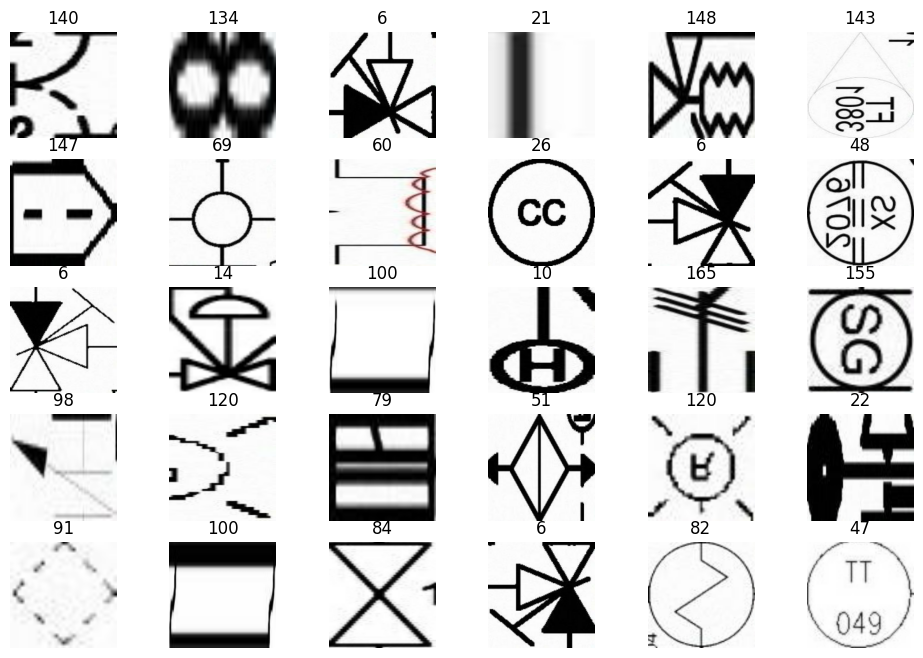

In [ ]:
fig, axes = plt.subplots(5, 6, figsize=(12, 8))
for i, (image, label) in enumerate(raw_train_dataset.take(30)):
  ax = axes[i // 6, i % 6]
  ax.imshow(tf.cast(image, tf.uint8))
  ax.set_title(f"{tf.argmax(label).numpy()}")
  ax.axis('off')

plt.show()

In [ ]:
def resize_normalize_img(image, label):
  """Normalizes images: `uint8` -> `float32`."""
  image = tf.image.resize(image, (CONFIG['IM_SIZE'], CONFIG['IM_SIZE']))
  return tf.cast(image, tf.float32) / 255., label

In [ ]:
# train dataset
train_dataset = (
    raw_train_dataset
    # .map(resize_normalize_img)
    .shuffle(buffer_size=10000, reshuffle_each_iteration=True)
    .batch(CONFIG['BATCH_SIZE'])
    .prefetch(tf.data.AUTOTUNE)
)


# validation dataset
valid_datast = (
    valid_dataset
    # .map(resize_normalize_img)
    .shuffle(buffer_size=10000, reshuffle_each_iteration=True)
    .batch(CONFIG['BATCH_SIZE'])
)


# test dataset
# test_dataset = (
#     test_dataset
#     .map(normalize_img)
#     .shuffle(buffer_size=1024, reshuffle_each_iteration=True)
# )

### Model Training
  - efficnetnet
  - mobilenet

In [ ]:
# eff_net_b3 = tf.keras.applications.MobileNetV2(
#     input_shape=(CONFIG['IM_SIZE'], CONFIG['IM_SIZE'], 3),
#     include_top=False,
#     weights='imagenet',
# )

eff_net_b3 = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights='imagenet',
    input_tensor=None,
    input_shape=(CONFIG['IM_SIZE'], CONFIG['IM_SIZE'], 3),
)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
eff_net_b3.trainable = True

In [ ]:
# Load your previously trained model
base_model_path = "/content/drive/MyDrive/Symbol_Detection/Classification/classification_models/eff_net_b3.keras"
eff_net_b3 = tf.keras.models.load_model(base_model_path)

# Freeze conv layers
for layer in eff_net_b3.layers:
    layer.trainable = False

# extract the feature extractor
feature_output = eff_net_b3.layers[-7]

In [ ]:
classifier = tf.keras.layers.Flatten()(eff_net_b3.output)
classifier = tf.keras.layers.Dense(CONFIG['DENSE_2'], activation='relu')(classifier)
classifier = tf.keras.layers.Dropout(CONFIG['DROPOUT'])(classifier)
classifier = tf.keras.layers.Dense(CONFIG['DENSE_3'], activation='relu')(classifier)
# classifier = tf.keras.layers.BatchNormalization()(classifier)
# classifier = tf.keras.layers.Dense(CONFIG['DENSE_3'], 'relu')(classifier)
classifier = tf.keras.layers.Dense(20, activation='softmax')(classifier)
eff_net_b3 = tf.keras.Model(inputs=eff_net_b3.input, outputs=classifier)
eff_net_b3.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        960 │ block1a_se_excit

 Total params: 13,192,883 (50.33 MB)

 Trainable params: 13,105,580 (49.99 MB)

 Non-trainable params: 87,303 (341.03 KB)

In [ ]:
eff_net_b3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG['LEARNING_RATE']),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=[tf.keras.metrics.CategoricalAccuracy(name="categ_acc"), tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top_5_acc')]
)

In [ ]:
eff_net_b3_history = eff_net_b3.fit(
    train_dataset,
    validation_data=valid_datast,
    epochs=CONFIG['EPOCHS'],
    verbose=1
)

Epoch 1/70
125/125 ━━━━━━━━━━━━━━━━━━━━ 239s 915ms/step - categ_acc: 0.1227 - loss: 2.8515 - top_5_acc: 0.3902 - val_categ_acc: 0.0667 - val_loss: 3.1165 - val_top_5_acc: 0.2667
Epoch 2/70
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 254ms/step - categ_acc: 0.3818 - loss: 2.0080 - top_5_acc: 0.7717 - val_categ_acc: 0.1333 - val_loss: 3.0662 - val_top_5_acc: 0.3500
Epoch 3/70
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 254ms/step - categ_acc: 0.5435 - loss: 1.5014 - top_5_acc: 0.8842 - val_categ_acc: 0.3167 - val_loss: 2.1119 - val_top_5_acc: 0.7000
Epoch 4/70
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 253ms/step - categ_acc: 0.6651 - loss: 1.1550 - top_5_acc: 0.9208 - val_categ_acc: 0.5500 - val_loss: 1.6024 - val_top_5_acc: 0.8333
Epoch 5/70
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 256ms/step - categ_acc: 0.7305 - loss: 0.9352 - top_5_acc: 0.9567 - val_categ_acc: 0.6167 - val_loss: 1.3488 - val_top_5_acc: 0.9167
Epoch 6/70
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 253ms/step - categ_acc: 0.7830 - loss: 0.7790 - top_5_acc: 0.9638 - va

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(eff_net_b3_history.history['loss'], label='Training Loss')
ax[0].plot(eff_net_b3_history.history['val_loss'], label='Validation Loss')
plt.xlabel("EPOCHS")
plt.ylabel("LOSS")
ax[0].legend()

ax[1].plot(eff_net_b3_history.history['categ_acc'], label="Training Accuracy")
ax[1].plot(eff_net_b3_history.history['val_categ_acc'], label="Validation Accuracy")
ax[1].plot(eff_net_b3_history.history['top_5_acc'], label="Training Top: 5 Accuracy")
ax[1].plot(eff_net_b3_history.history['val_top_5_acc'], label="Validation Top: 5 Accuracy")

plt.xlabel("EPOCHS")
plt.ylabel("ACCURACY")
ax[1].legend()
plt.show()

In [ ]:
classfication_model_save_root = "/content/drive/MyDrive/Symbol_Detection/Classification/classification_models/"
model_save_path = os.path.join(classfication_model_save_root, "eff_net_b3_batch_03.keras")

eff_net_b3.save(model_save_path)

In [ ]:
eff_net_b3.evaluate(valid_datast)

In [ ]:
x, y = next(iter(valid_datast.shuffle(1024, reshuffle_each_iteration=True)))


print(x.shape, y.numpy())

In [ ]:
x[0].shape

In [ ]:
img_batch, lbl_batch = next(iter(valid_datast.shuffle(1024, reshuffle_each_iteration=True)))

root_save_ = "/content/classification_results/"
os.makedirs(root_save_, exist_ok=True)
for i in range(CONFIG['BATCH_SIZE']):
  img = img_batch[i]
  y = lbl_batch[i]
  img = tf.expand_dims(img, axis=0)
  pred = eff_net_b3.predict(img)
  pred_ = tf.argmax(pred, axis=-1)


  plt.figure(figsize=(4, 4))
  plt.imshow(img[0])
  plt.title("Actuat Label: {}\nPredicted Label: {}".
            format(tf.argmax(y).numpy(), pred_.numpy()[0]))
  plt.axis('off')
  saving_path = os.path.join(root_save_, f'fig_{i}.jpg')
  plt.savefig(saving_path)
  plt.show()

In [ ]:
!zip -r /content/classification_results.zip /content/classification_results/

### Hugging Face Transformer

### CustomVit SubClass Model

In [ ]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath="best_model_weights.h5",   # where to save
    monitor="val_loss",                 # metric to watch
    save_best_only=True,                # only keep best
    mode="min",                         # "min" because lower val_loss = better
    verbose=1
)

In [ ]:
!pip install -q tensorflow==2.18.1
!pip install -q keras==3.9.2
!pip install -q transformers==4.56.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.6/615.6 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 123.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.18.1 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.18.1 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.18.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 

In [ ]:
from transformers import TFViTModel

In [ ]:
# Custom Hugging Face sub class model

class CustomVit(tf.keras.Model):
  def __init__(self, n_classes, **kwargs):
    super(CustomVit, self).__init__(name="CustomVit")

    self.n_classes = n_classes

    self.resize_rescale_layer = tf.keras.Sequential([
        tf.keras.layers.Resizing(224, 224),
        tf.keras.layers.Rescaling(1./255),
        tf.keras.layers.Permute((3, 1, 2))
    ])

    self.base_model = TFViTModel.from_pretrained('google/vit-base-patch16-224-in21k', from_pt=True)
    self.classifier = tf.keras.layers.Dense(n_classes, activation='softmax')


  def call(self, input):

    x = self.resize_rescale_layer(input)
    x = self.base_model.vit(x)[0][:, 0, :]
    output = self.classifier(x)

    return output

  def get_config(self):
      config = super().get_config()
      config.update({"n_classes": self.n_classes})
      return config

  @classmethod
  def from_config(cls, config):
      return cls(**config)

In [ ]:
custom_vit = CustomVit(CONFIG['N_CLASSES'])
# custom_vit(tf.zeros([32, 256, 256, 3]))
# custom_vit.summary()

In [ ]:
custom_vit.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG['LEARNING_RATE']),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=[tf.keras.metrics.CategoricalAccuracy()]
)

In [ ]:
vit_histroy = custom_vit.fit(train_dataset,
          epochs=CONFIG['EPOCHS'],
          validation_data=valid_datast,
          verbose=1)

Epoch 1/33
673/673 ━━━━━━━━━━━━━━━━━━━━ 1056s 2s/step - categorical_accuracy: 0.0117 - loss: 5.1917 - val_categorical_accuracy: 0.0398 - val_loss: 5.0534
Epoch 2/33
673/673 ━━━━━━━━━━━━━━━━━━━━ 1107s 2s/step - categorical_accuracy: 0.0623 - loss: 4.9970 - val_categorical_accuracy: 0.1160 - val_loss: 4.8757
Epoch 3/33
673/673 ━━━━━━━━━━━━━━━━━━━━ 1048s 2s/step - categorical_accuracy: 0.1574 - loss: 4.8106 - val_categorical_accuracy: 0.1819 - val_loss: 4.7044
Epoch 4/33
673/673 ━━━━━━━━━━━━━━━━━━━━ 1013s 2s/step - categorical_accuracy: 0.2324 - loss: 4.6314 - val_categorical_accuracy: 0.2507 - val_loss: 4.5384
Epoch 5/33
673/673 ━━━━━━━━━━━━━━━━━━━━ 1042s 2s/step - categorical_accuracy: 0.2955 - loss: 4.4585 - val_categorical_accuracy: 0.2986 - val_loss: 4.3771
Epoch 6/33
673/673 ━━━━━━━━━━━━━━━━━━━━ 1013s 2s/step - categorical_accuracy: 0.3427 - loss: 4.2916 - val_categorical_accuracy: 0.3542 - val_loss: 4.2202
Epoch 7/33
673/673 ━━━━━━━━━━━━━━━━━━━━ 1013s 2s/step - categorical_accuracy

KeyboardInterrupt: 

In [ ]:
20:55

In [ ]:
import tensorflow as tf
import transformers as tfm
import tensorflow.keras as k
print(tf.__version__, tfm.__version__, k.__version__)

2.19.0 4.56.1 3.10.0


In [ ]:
custom_vit.save("human-emotion-detection-vit-model_1.keras")

In [ ]:
!rm -rf /content/my_models

In [ ]:
import tensorflow as tf

model_path = "/content/model_epoch_20.keras"
classifier_model = tf.keras.models.load_model(model_path,
                                       custom_objects={"CustomVit": CustomVit(184)})

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/346M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All PyTorch model weights were used when initializing TFViTModel.

All the weights of TFViTModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFViTModel for predictions without further training.
All PyTorch model weights were used when initializing TFViTModel.

All the weights of TFViTModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFViTModel for predictions without further training.


In [ ]:
classifier_model.summary()

Model: "CustomVit"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 3, 224, 224)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 184)            │       141,496 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,490 (1.62 MB)

 Trainable params: 141,496 (552.72 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 282,994 (1.08 MB)

In [ ]:
class SaveModelEachEpoch(tf.keras.callbacks.Callback):
    def __init__(self, save_dir="/content/saved_models"):
        super().__init__()
        self.save_dir = save_dir
        os.makedirs(self.save_dir, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        filename = f"model_epoch_{epoch+1}.keras"
        filepath = os.path.join(self.save_dir, filename)
        self.model.save(filepath)
        print(f"\nModel saved at: {filepath}")

# Usage example while training
save_callback = SaveModelEachEpoch(save_dir="/content/my_models")

In [ ]:
classifier_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG['LEARNING_RATE']),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=[tf.keras.metrics.CategoricalAccuracy()]
)

In [ ]:
vit_histroy = classifier_model.fit(train_dataset,
          epochs=CONFIG['EPOCHS'],
          validation_data=valid_datast,
          verbose=1,
          callbacks=[save_callback])

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - categorical_accuracy: 0.9023 - loss: 0.5295
Model saved at: /content/my_models/model_epoch_1.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 1148s 1s/step - categorical_accuracy: 0.9023 - loss: 0.5295 - val_categorical_accuracy: 0.8970 - val_loss: 0.5513
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - categorical_accuracy: 0.9054 - loss: 0.5194
Model saved at: /content/my_models/model_epoch_2.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 1107s 1s/step - categorical_accuracy: 0.9054 - loss: 0.5194 - val_categorical_accuracy: 0.8986 - val_loss: 0.5449
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - categorical_accuracy: 0.9061 - loss: 0.5148
Model saved at: /content/my_models/model_epoch_3.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 1108s 1s/step - categorical_accuracy: 0.9061 - loss: 0.5148 - val_categorical_accuracy: 0.9001 - val_loss: 0.5390
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - categorical_accuracy: 0.9074 - loss: 0.5067
Model saved at: /c

In [ ]:
classifier_model.save("human-emotion-detection-vit-model_5.keras")

In [ ]:
classifier_model.evaluate(valid_datast)

33/33 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - categorical_accuracy: 0.8670 - loss: 0.7858


[0.7909008264541626, 0.8650850653648376]

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os
import json



def run_inference(img_path, classifier_model, save_dir, classes_list):
  """ Run inference on custom vit trained classifier for PIND symobls

  Args:
    img_path: input image path
    classifier_model: the classifer model
    save_dir: directory where results will saves
    classes_list: list of classes

  Returns:
    None
  """

  os.makedirs(save_dir, exist_ok=True)
  img = cv2.imread(img_path)
  img = tf.expand_dims(img, axis=0)
  pred = classifier_model.predict(img)
  pred_ = tf.argmax(pred, axis=-1)
  conf = pred[0][pred_.numpy()[0]]
  predicted_class = classes_list[pred_.numpy()[0]]

  plt.figure(figsize=(4, 4))
  plt.imshow(img[0])
  plt.title("P_lbl: {}\nconf: {:.3f}".
            format(predicted_class, conf))
  plt.axis('off')
  save_path = os.path.join(save_dir, os.path.basename(img_path))
  print(f"Result saved to {save_path}")
  plt.savefig(save_path)
  plt.close()



# === configs ===
classes_list_path = "/content/classes_list.json"
with open(classes_list_path, 'r') as f_r:
  classes_list = json.load(f_r)
print(f"{len(classes_list)} classes loaded")

input_image = "/content/symbol_dataset/test/Back Pressure Valve/134_0_high__th__symbol_7_0_7_Globe Type Control Valve.jpg"
run_inference(input_image, classifier_model, "/content/tests", classes_list)

184 classes loaded
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Result saved to /content/tests/134_0_high__th__symbol_7_0_7_Globe Type Control Valve.jpg


In [ ]:
print(pred_, conf, "\n",pred)

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt

testing_path = "/content/classifier_tests"
input_testing_path = "/content/symbol_dataset/test"
os.makedirs(testing_path, exist_ok=True)

for label_idx, folder in enumerate(sorted(os.listdir(input_testing_path))):
  print(folder)
  # -- paths configuration --
  folder_path = os.path.join(input_testing_path, folder)
  testing_folder = os.path.join(testing_path, folder)
  os.makedirs(testing_folder, exist_ok=True)

  for idx, img_path in enumerate(os.listdir(folder_path)):
    img = cv2.imread(os.path.join(folder_path, img_path))
    img = tf.expand_dims(img, axis=0)
    pred = classifier_model.predict(img)
    pred_ = tf.argmax(pred, axis=-1)
    conf = pred[0][pred_.numpy()[0]]
    predicted_class = folder if label_idx == pred_.numpy()[0] else "Wrong-Pred"

    plt.figure(figsize=(4, 4))
    plt.imshow(img[0])
    plt.title("A_lbl: {}\nP_lbl: {}\nconf: {:.3f}".
              format(folder,  predicted_class, conf))
    plt.axis('off')
    plt.savefig(os.path.join(testing_folder, f"fig_{idx}.jpg"))
    plt.close()

    if idx == 20: break
  # if label_idx == 2: break

In [ ]:
!rm -rf /content/tests

In [ ]:
!zip -r classification_test.zip /content/tests

## Model Testing

### model evaluation

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt

testing_path = "/content/classifier_tests"
input_testing_path = "/content/symbol_dataset/test"
os.makedirs(testing_path, exist_ok=True)

for label_idx, folder in enumerate(sorted(os.listdir(input_testing_path))):
  print(folder)
  # -- paths configuration --
  folder_path = os.path.join(input_testing_path, folder)
  testing_folder = os.path.join(testing_path, folder)
  os.makedirs(testing_folder, exist_ok=True)

  for idx, img_path in enumerate(os.listdir(folder_path)):
    img = cv2.imread(os.path.join(folder_path, img_path))
    img = tf.expand_dims(img, axis=0)
    pred = classifier_model.predict(img)
    pred_ = tf.argmax(pred, axis=-1)
    conf = pred[0][pred_.numpy()[0]]
    predicted_class = folder if label_idx == pred_.numpy()[0] else "Wrong-Pred"

    plt.figure(figsize=(4, 4))
    plt.imshow(img[0])
    plt.title("A_lbl: {}\nP_lbl: {}\nconf: {:.3f}".
              format(folder,  predicted_class, conf))
    plt.axis('off')
    plt.savefig(os.path.join(testing_folder, f"fig_{idx}.jpg"))
    plt.close()

    if idx == 20: break
  # if label_idx == 2: break

In [ ]:

for label, folder in enumerate(sorted(os.listdir("/content/symbol_dataset/test"))):

  if label < 180: continue
  print(label, folder)

180 Y Type Strainer
181 line split arrows
182 plc
183 turbine type


In [ ]:
import tensorflow as tf
import cv2
import os
import matplotlib.pyplot as plt
import json
import pandas as pd




def load_modal(model_path, n_classes=184):
  "Load the PNID classifier model"
  model = tf.keras.models.load_model(model_path,
                            custom_objects={"CustomVit": CustomVit(n_classes)})
  return model



class Model_Testing:
  def __init__(self, model,
               test_root, save_test, csv_path,
               classes_list, n_classes=184):

    self.model = model
    self.test_root = test_root
    self.save_test = save_test
    self.csv_path = csv_path
    self.classes_list = classes_list
    self.predict_list = []


  def _run_inference(self, image):
    """ Run inference on custom vit trained classifier for PIND symobls
    """
    pred = self.model.predict(image, verbose=0)
    pred_id = tf.argmax(pred, axis=-1)[0]
    conf = pred[0][pred_id.numpy()]
    pred_class = self.classes_list[pred_id]

    return pred_id, pred_class, conf


  def _read_image(self, img_path):
    """ Read image from path
    """
    assert os.path.exists(img_path), f"image {img_path} not found"

    image = cv2.imread(img_path)
    if len(image.shape) == 2:
      image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    image = tf.expand_dims(image, axis=0)

    return image


  def _save_image(self, image, save_path, folder, predicted_class, conf):
    """ Save the predicted image"""
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(image)
    ax.set_title("A_lbl: {}\nP_lbl: {}\nconf: {:.3f}".
              format(folder,  predicted_class, conf))
    ax.axis('off')
    fig.savefig(save_path)
    plt.close()



  def _update_statistics(self, folder, total_images, pred_correct, pred_wrong):
    """ Update the statistics
    """
    percent = 100
    correct_perc = (pred_correct / total_images) * percent
    wrong_prec = (pred_wrong / total_images) * percent
    self.predict_list.append([folder, total_images, pred_correct, pred_wrong, correct_perc, wrong_prec])
    print("\nStatistics Updated, Scores Class: {} - Total Imges: {} - Correct Pred: {} - Mis Pred: {}"
          .format(folder, total_images, pred_correct, pred_wrong))


  def _save_statistics(self, save_path):
    """ Save the statistics
    """
    df = pd.DataFrame(self.predict_list, columns=["Class", "Total Images", "Correct Pred", "Wrong Pred", "Correct %", "Wrong %"])
    df.to_csv(save_path, index=False)
    print("\nStatistics saved at {}".format(save_path))




  def main(self):
    """ Main function
    """
    for label_idx, folder in enumerate(sorted(os.listdir(self.test_root))):
      # -- vars --
      total_images = 0
      pred_correct = 0
      pred_wrong = 0

      if label_idx < 180: continue


      # -- paths configuration --
      folder_path = os.path.join(self.test_root, folder)
      testing_folder = os.path.join(self.save_test, folder)
      testing_folder_correct = os.path.join(testing_folder, "correct")
      testing_folder_wrong = os.path.join(testing_folder, "wrong")

      os.makedirs(testing_folder, exist_ok=True)
      os.makedirs(testing_folder_correct, exist_ok=True)
      os.makedirs(testing_folder_wrong, exist_ok=True)


      # -- Processing Images --
      print("\nTotal Files: {} - Processing Folder: {} ...........".format(len(os.listdir(folder_path)), folder))
      for im_idx, img_path in enumerate(os.listdir(folder_path)):

        # --- path configs ---
        read_img_path = os.path.join(folder_path, img_path)
        write_img_path_correct = os.path.join(testing_folder_correct, os.path.basename(img_path))
        write_img_path_wrong = os.path.join(testing_folder_wrong, os.path.basename(img_path))
        print("File: {} - Processing image {}".format(im_idx, read_img_path))


        # --- run inference ---
        image = self._read_image(read_img_path)
        pred_id, pred_class, conf = self._run_inference(image)
        predicted_class = folder if label_idx == pred_id else "Wrong-Pred"


        # --- save infer image & update vars ---
        total_images += 1
        if predicted_class != "Wrong-Pred":
          pred_correct += 1
          self._save_image(image[0], write_img_path_correct, folder, predicted_class, conf)
          print("Prediction saved at {}".format(write_img_path_correct))
        else:
          pred_wrong += 1
          self._save_image(image[0], write_img_path_wrong, folder, predicted_class, conf)
          print("Prediction saved at {}".format(write_img_path_wrong))
        # if im_idx == 3: break

      # -- Update the statistics --
      self._update_statistics(folder, total_images, pred_correct, pred_wrong)
      # if label_idx == 4: break

    # -- save statistics --
    self._save_statistics(self.csv_path)



if __name__=="__main__":

  # == Paths Configurations ==
  model_path = "/content/model_epoch_20.keras"
  test_root = "/content/symbol_dataset/test"
  test_save = "/content/Classifer_Tests"
  csv_path = "/content/statistics.csv"
  classes_path = "/content/classes_list.json"


  # == Loads Classes & Models ==
  model = load_modal(model_path)
  print("\n\nModel Loaded")

  with open(classes_path, 'r') as f_r:
    classes_list = json.load(f_r)
  print(f"{len(classes_list)} classes loaded")


  # == Class Configurations ==
  model_testing = Model_Testing(model, test_root, test_save, csv_path, classes_list)
  model_testing.main()


All PyTorch model weights were used when initializing TFViTModel.

All the weights of TFViTModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFViTModel for predictions without further training.
All PyTorch model weights were used when initializing TFViTModel.

All the weights of TFViTModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFViTModel for predictions without further training.




Model Loaded
184 classes loaded

Total Files: 25 - Processing Folder: Y Type Strainer ...........
File: 0 - Processing image /content/symbol_dataset/test/Y Type Strainer/aug_228_symbol_8_513_42_Y Type Strainer.jpg
Prediction saved at /content/Classifer_Tests/Y Type Strainer/correct/aug_228_symbol_8_513_42_Y Type Strainer.jpg
File: 1 - Processing image /content/symbol_dataset/test/Y Type Strainer/aug_262_97_5_high__tn__symbol_2_449_13_Y Type Strainer.jpg
Prediction saved at /content/Classifer_Tests/Y Type Strainer/correct/aug_262_97_5_high__tn__symbol_2_449_13_Y Type Strainer.jpg
File: 2 - Processing image /content/symbol_dataset/test/Y Type Strainer/aug_242_symbol_8_513_45_Y Type Strainer.jpg
Prediction saved at /content/Classifer_Tests/Y Type Strainer/wrong/aug_242_symbol_8_513_45_Y Type Strainer.jpg
File: 3 - Processing image /content/symbol_dataset/test/Y Type Strainer/aug_345_97_4_low__tn__symbol_3_72_50_Y Type Strainer.jpg
Prediction saved at /content/Classifer_Tests/Y Type Stra

In [ ]:
!zip -r /content/classifier_tests.zip /content/Classifer_Tests

  adding: content/Classifer_Tests/ (stored 0%)
  adding: content/Classifer_Tests/Screw Compressor/ (stored 0%)
  adding: content/Classifer_Tests/Screw Compressor/wrong/ (stored 0%)
  adding: content/Classifer_Tests/Screw Compressor/correct/ (stored 0%)
  adding: content/Classifer_Tests/Screw Compressor/correct/aug_426_58_10_high__th__symbol_9_20_0_Screw Compressor.jpg (deflated 16%)
  adding: content/Classifer_Tests/Screw Compressor/correct/aug_179_58_3_low__tn__symbol_9_20_18_Screw Compressor.jpg (deflated 14%)
  adding: content/Classifer_Tests/Screw Compressor/correct/aug_148_58_2_high__th__symbol_9_383_41_Screw Compressor.jpg (deflated 18%)
  adding: content/Classifer_Tests/Screw Compressor/correct/aug_229_symbol_9_177_46_Screw Compressor.jpg (deflated 12%)
  adding: content/Classifer_Tests/Screw Compressor/correct/symbol_9_383_41_Screw Compressor.jpg (deflated 13%)
  adding: content/Classifer_Tests/Screw Compressor/correct/aug_409_symbol_9_177_45_Screw Compressor.jpg (deflated 13%)

In [ ]:
!cp -r /content/classifier_tests.zip /content/drive/MyDrive/Symbol_Detection/Classification/Classes_Analytics/Class_Prediction_Analysis/

In [ ]:
!cp -r /content/classes_statistics.csv /content/drive/MyDrive/Symbol_Detection/Classification/Classes_Analytics/Class_Prediction_Analysis/

### confusion matrix

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

testing_path = "/content/classifier_tests"
input_testing_path = "/content/symbol_dataset/test"
os.makedirs(testing_path, exist_ok=True)

# store all ground-truth and predictions
y_true = []
y_pred = []
class_names = sorted(os.listdir(input_testing_path))

for label_idx, folder in enumerate(class_names):
    folder_path = os.path.join(input_testing_path, folder)
    print(f"No: {label_idx} - Processing folder: {folder_path}")
    for img_idx, img_path in enumerate(os.listdir(folder_path)):
        img = cv2.imread(os.path.join(folder_path, img_path))
        img = tf.expand_dims(img, axis=0)

        pred = model_xyz.predict(img, verbose=0)
        pred_class = tf.argmax(pred, axis=-1).numpy()[0]

        y_true.append(label_idx)
        y_pred.append(pred_class)

        if img_idx==20:
          break

No: 0 - Processing folder: /content/symbol_dataset/test/2 Way Angle Valve With Handle
No: 1 - Processing folder: /content/symbol_dataset/test/2 Way Filled SYS
No: 2 - Processing folder: /content/symbol_dataset/test/2 Way Valve
No: 3 - Processing folder: /content/symbol_dataset/test/2 Way Valve With Actuator
No: 4 - Processing folder: /content/symbol_dataset/test/3 Way Pressure Safety Valve
No: 5 - Processing folder: /content/symbol_dataset/test/3 Way Valve
No: 6 - Processing folder: /content/symbol_dataset/test/3 Way Valve With Actuator
No: 7 - Processing folder: /content/symbol_dataset/test/3 way ball valve
No: 8 - Processing folder: /content/symbol_dataset/test/3 way globe valve
No: 9 - Processing folder: /content/symbol_dataset/test/3-WAY SOLENOID VALVE
No: 10 - Processing folder: /content/symbol_dataset/test/Actuator
No: 11 - Processing folder: /content/symbol_dataset/test/Air Filter
No: 12 - Processing folder: /content/symbol_dataset/test/Angular Valve
No: 13 - Processing folder: 

In [ ]:
# build confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))

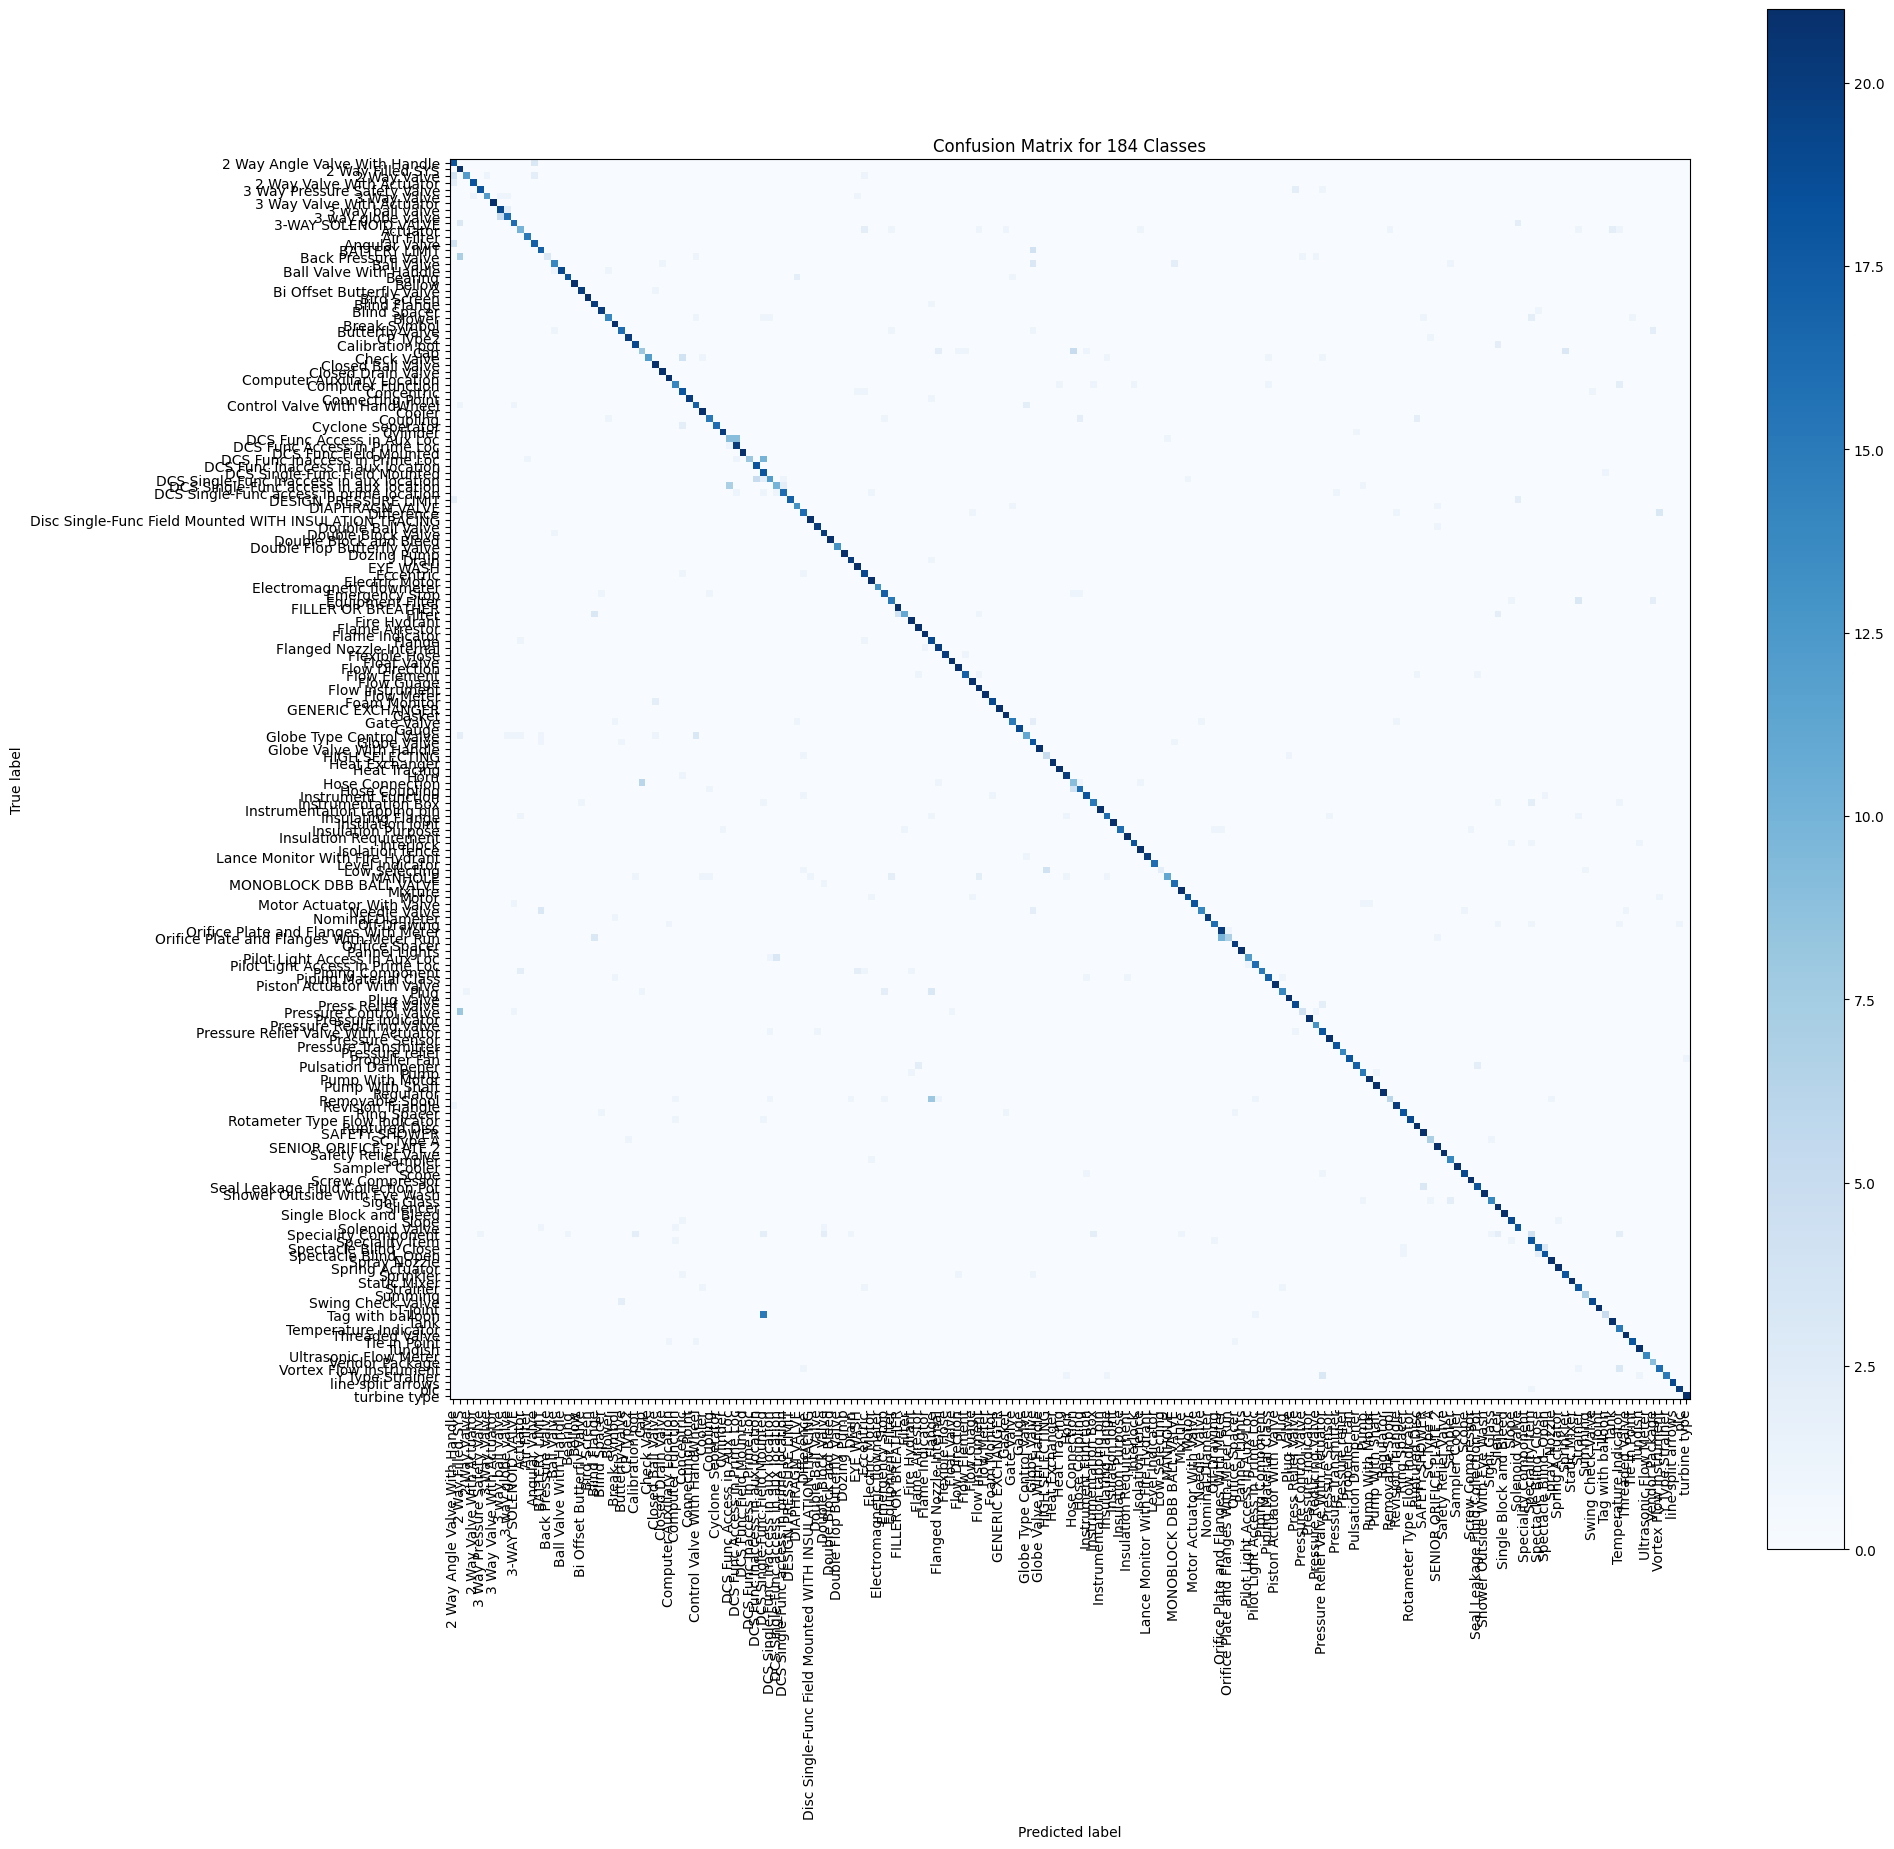

In [ ]:
# plot it
plt.figure(figsize=(20, 20))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(include_values=False, cmap="Blues", xticks_rotation=90, ax=plt.gca())
plt.title("Confusion Matrix for 184 Classes")
plt.show()

#### Black Box

In [ ]:
vgg_net_model.summary()

In [ ]:
# feature extracter model
last_conv_layer = "block5_pool"
last_conv_layer = vgg_net_model.get_layer(last_conv_layer)
last_conv_model = tf.keras.Model(inputs=vgg_net_model.input, outputs=last_conv_layer.output)
last_conv_model.summary()

In [ ]:
# classifier model
classifier_layers_name = ['flatten_4', 'dense_12', 'dropout_4', 'dense_13', 'dense_14']
classifier_input = tf.keras.layers.Input(shape=(7, 7, 512))
x = classifier_input
for layer_name in classifier_layers_name:
  x = vgg_net_model.get_layer(layer_name)(x)

classifier_model = tf.keras.Model(inputs=classifier_input, outputs=x)
classifier_model.summary()

In [ ]:
img, label = next(iter(test_dataset))
img = tf.expand_dims(img, axis=0)
print(img.shape, label)

In [ ]:
with tf.GradientTape() as tape:
  last_conv_output = last_conv_model(img)
  preds = classifier_model(last_conv_output)
  top_class = tf.argmax(preds[0])
  class_channel = preds[:, top_class]
  grad = tape.gradient(class_channel, last_conv_output)

In [ ]:
pooled_grads = tf.reduce_mean(grad, axis=(0, 1, 2))  # shape: (channels,)

# last_conv_output shape: (1, H, W, channels)
last_conv_output = last_conv_output[0]  # remove batch dimension

# Scale each channel
heatmap = last_conv_output @ pooled_grads[..., tf.newaxis]  # shape: (H, W, 1)
heatmap = tf.squeeze(heatmap)  # shape: (H, W)

heatmap = tf.maximum(heatmap, 0)
heatmap /= tf.reduce_max(heatmap)

In [ ]:
import cv2
import numpy as np

heatmap = heatmap.numpy()
heatmap = cv2.resize(heatmap, (img.shape[2], img.shape[1]))  # W, H

# Convert to RGB if needed
img_rgb = img[0].numpy()
if img_rgb.max() <= 1.0:
    img_rgb = (img_rgb * 255).astype(np.uint8)

# Apply colormap
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)

# Superimpose
superimposed_img = cv2.addWeighted(img_rgb, 0.6, heatmap_colored, 0.4, 0)

# Display
import matplotlib.pyplot as plt
plt.imshow(superimposed_img)
plt.axis('off')
plt.title('Grad-CAM')
plt.show()

### Implementing [Testing]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
data_path_01 = "/content/drive/MyDrive/Symbol_Detection/Classification/Raw_Images_Symbols/Testing_Images_symbols-no\ duplicate\ templates.zip"


!unzip -q {data_path_01} -d /content/data_01

In [ ]:
import cv2 as cv
import numpy as np
import os
import time


def read_img(path):
  img_rgb = cv.imread(diagram_path)
  assert img_rgb is not None, "file could not be read, check with os.path.exists()"
  img_gray = cv.cvtColor(img_rgb, cv.COLOR_BGR2GRAY)

  return img_gray


def detect_symbols(symbol_paths, img_gray):
  object_list = []

  # iterate through each symbol in the symbol image folder
  for i in range(len(symbol_paths)):
    # temporarily add i to the symbol to separate them.
    symbol_name = f'sym_{i}'

    if not symbol_paths[i].endswith('.jpg'): continue
    template = cv.imread(symbol_paths[i], cv.IMREAD_GRAYSCALE)
    # add a transpose augmentation to the symbol for now
    temp_iterations = []
    temp_iterations.append(template)
    temp_iterations.append(template.transpose())

    # for each symbol, loop through each iteration and do a matchtemplate pass
    for temp in temp_iterations:
      w, h = temp.shape[::-1]
      res = cv.matchTemplate(img_gray,temp,cv.TM_CCOEFF_NORMED)
      threshold = 0.61
      loc = np.where( res >= threshold)
      for pt in zip(*loc[::-1]):
        # if coordinate matches add object to object list
        # object consists of ((coord), symbol name, height, width, confidence)
        object_list.append((pt, symbol_name, h, w, res[pt[1], pt[0]]))
  return object_list


def separate_overlapping_rectangles(obj_list):
    overlapping_lists = []

    for rect1 in obj_list:
        x1, y1  = rect1[0]
        width1  = rect1[3]
        height1 = rect1[2]
        overlap_found = False
        for overlap_list in overlapping_lists:
            for rect2 in overlap_list:
                x2, y2 = rect2[0]
                width2 = rect2[3]
                height2 = rect2[2]
                if (x1 < x2 + width2) and (x1 + width1 > x2) and (y1 < y2 + height2) and (y1 + height1 > y2):
                    overlap_list.append(rect1)
                    overlap_found = True
                    break
            if overlap_found:
                break
        if not overlap_found:
            overlapping_lists.append([rect1])

    return overlapping_lists


def final_object_selection(overlapping_object_list):
  final_object_list = []
  for overlapping_list in overlapping_object_list:
    if len(overlapping_list) > 1:
      max_index = max(range(len(overlapping_list)), key=lambda i: overlapping_list[i][4])
      final_object_list.append(overlapping_list[max_index])
    else:
      final_object_list.append(overlapping_list[0])
  len(final_object_list)
  return final_object_list


def annotation(final_object_list, img_rgb):
  annotation_txt = []
  for object in final_object_list:
    cv.rectangle(img_rgb, object[0], (object[0][0] + object[3], object[0][1] + object[2]), (0,0,255), 2)
    cv.putText(img_rgb, object[1], (object[0][0], object[0][1]-12), cv.FONT_HERSHEY_PLAIN, 1.5, (0,0,180), 2)
    x1 = object[0][0]
    y1 = object[0][1]
    x2 = object[0][0]
    y2 = object[0][1] + object[3]
    x3 = object[0][0] + object[2]
    y3 = object[0][1] + object[3]
    x4 = object[0][0] + object[2]
    y4 = object[0][1]
    annotation_txt.append((x1, y1, x2, y2, x3, y3, x4, y4, object[1]))
  cv.imwrite(output_path,img_rgb)

In [ ]:
if __name__ == '__main__':
  start_time = time.time()
  diagram_path = '/content/data_01/Testing_Images_symbols-no duplicate templates/P14456A-14-01-08-0645-2/bw_image_1_P14456A-14-01-08-0645-2.jpg'
  symbol_dir = '/content/data_01/Testing_Images_symbols-no duplicate templates/symbols'
  output_path = 'template_match.png'

  # -- reading image & symbols path --
  img_gray = read_img(diagram_path)
  symbol_paths = [f'{symbol_dir}/{f}' for f in os.listdir(symbol_dir)]


  # -- detect symbols --
  object_list = detect_symbols(symbol_paths, img_gray)


  # -- handle overlap symbols --
  overlapping_object_list = separate_overlapping_rectangles(object_list)


  # -- final object selection --
  final_object_list = final_object_selection(overlapping_object_list)


  # -- draw over image --
  annotation(final_object_list, img_gray)

In [ ]:
# Provided two tensors t1 and t2
# Euclidean distance = sqrt(sum(square(t1-t2)))
def euclidean_distance(vects):
    """Find the Euclidean distance between two vectors.

    Arguments:
        vects: List containing two tensors of same length.

    Returns:
        Tensor containing euclidean distance
        (as floating point value) between vectors.
    """

    x, y = vects
    sum_square = ops.sum(ops.square(x - y), axis=1, keepdims=True)
    return ops.sqrt(ops.maximum(sum_square, keras.backend.epsilon()))


input = keras.layers.Input((28, 28, 1))
x = keras.layers.BatchNormalization()(input)
x = keras.layers.Conv2D(4, (5, 5), activation="tanh")(x)
x = keras.layers.AveragePooling2D(pool_size=(2, 2))(x)
x = keras.layers.Conv2D(16, (5, 5), activation="tanh")(x)
x = keras.layers.AveragePooling2D(pool_size=(2, 2))(x)
x = keras.layers.Flatten()(x)

x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dense(10, activation="tanh")(x)
embedding_network = keras.Model(input, x)


input_1 = keras.layers.Input((28, 28, 1))
input_2 = keras.layers.Input((28, 28, 1))

# As mentioned above, Siamese Network share weights between
# tower networks (sister networks). To allow this, we will use
# same embedding network for both tower networks.
tower_1 = embedding_network(input_1)
tower_2 = embedding_network(input_2)

merge_layer = keras.layers.Lambda(euclidean_distance, output_shape=(1,))(
    [tower_1, tower_2]
)
normal_layer = keras.layers.BatchNormalization()(merge_layer)
output_layer = keras.layers.Dense(1, activation="sigmoid")(normal_layer)
siamese = keras.Model(inputs=[input_1, input_2], outputs=output_layer)

In [ ]:
def loss(margin=1):
    """Provides 'contrastive_loss' an enclosing scope with variable 'margin'.

    Arguments:
        margin: Integer, defines the baseline for distance for which pairs
                should be classified as dissimilar. - (default is 1).

    Returns:
        'contrastive_loss' function with data ('margin') attached.
    """

    # Contrastive loss = mean( (1-true_value) * square(prediction) +
    #                         true_value * square( max(margin-prediction, 0) ))
    def contrastive_loss(y_true, y_pred):
        """Calculates the contrastive loss.

        Arguments:
            y_true: List of labels, each label is of type float32.
            y_pred: List of predictions of same length as of y_true,
                    each label is of type float32.

        Returns:
            A tensor containing contrastive loss as floating point value.
        """

        square_pred = ops.square(y_pred)
        margin_square = ops.square(ops.maximum(margin - (y_pred), 0))
        return ops.mean((1 - y_true) * square_pred + (y_true) * margin_square)

    return contrastive_loss

In [ ]:
siamese.compile(loss=loss(margin=margin), optimizer="RMSprop", metrics=["accuracy"])
siamese.summary()

In [ ]:
history = siamese.fit(
    [x_train_1, x_train_2],
    labels_train,
    validation_data=([x_val_1, x_val_2], labels_val),
    batch_size=batch_size,
    epochs=epochs,
)

In [ ]:
def plt_metric(history, metric, title, has_valid=True):
    """Plots the given 'metric' from 'history'.

    Arguments:
        history: history attribute of History object returned from Model.fit.
        metric: Metric to plot, a string value present as key in 'history'.
        title: A string to be used as title of plot.
        has_valid: Boolean, true if valid data was passed to Model.fit else false.

    Returns:
        None.
    """
    plt.plot(history[metric])
    if has_valid:
        plt.plot(history["val_" + metric])
        plt.legend(["train", "validation"], loc="upper left")
    plt.title(title)
    plt.ylabel(metric)
    plt.xlabel("epoch")
    plt.show()


# Plot the accuracy
plt_metric(history=history.history, metric="accuracy", title="Model accuracy")

# Plot the contrastive loss
plt_metric(history=history.history, metric="loss", title="Contrastive Loss")

In [ ]:
results = siamese.evaluate([x_test_1, x_test_2], labels_test)
print("test loss, test acc:", results)

In [ ]:
predictions = siamese.predict([x_test_1, x_test_2])
visualize(pairs_test, labels_test, to_show=3, predictions=predictions, test=True)

NameError: name 'siamese' is not defined